# Solutions: Statistical Decision Theory and the Bias-Variance Trade-off

This notebook contains worked solutions to the four exercises at the end of the practical notebook
*Statistical Decision Theory and the Bias-Variance Trade-off*. Every solution is written the way you were asked
to write yours: code first, then an explanation of what each line does, then a reading of the result.

**How to use this notebook**

1. Attempt the exercise yourself first. Reading a solution feels like understanding; writing one is understanding.
2. When you are stuck on a step, read only that step here, then go back to your own notebook.
3. After finishing, compare your approach with this one. A different approach that gets the same numbers is not
   wrong. In several places a comment points out the alternative you might have written.

**Two practical notes**

* **This notebook is self-contained.** Section 0 below re-creates every function and every variable from the
  practical, so you can run this file on its own without opening the practical first. Run the cells from top to
  bottom.
* **Your numbers may differ in the third decimal place.** The random-number generator is seeded with the same
  value, but this notebook does not make exactly the same sequence of random draws as the practical, so the
  datasets are not byte-for-byte identical. Quantities computed by integration (the Bayes error rate of a world,
  for example) will agree exactly; quantities estimated from a sample (a test error, a measured variance) will
  agree only to within sampling noise. Every conclusion is unaffected.

**Contents**

| exercise | topic | main idea it tests |
|---|---|---|
| 1 | unequal misclassification costs | the loss function, not the data, decides where the boundary goes |
| 2 | when a straight line is optimal | approximation error disappears when the model family fits the truth |
| 3 | bias and variance from one dataset | the bootstrap estimates variance, never bias |
| 4 | moving the sweet spot | data size, noise level and regularisation all reshape the U-curve |

---
## Section 0: Setup copied from the practical

The cells in this section are taken unchanged from the practical notebook. They are collected here so that this
file runs on its own. If you have just finished the practical, you already know all of this code, so read the
comments quickly and move on to Exercise 1.

In [25]:
import numpy as np                      # arrays, random sampling, all the numerical work
import pandas as pd                     # tables, so results print with readable labels
import matplotlib.pyplot as plt         # every plot in this notebook
import math                             # only for math.erf, used once in Exercise 2

%matplotlib inline

rng = np.random.default_rng(42)         # one seeded generator, so re-running gives identical numbers
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 330

In [26]:
# ---------- decision theory (Part 1 of the practical) ----------

LOSS_01 = np.array([[0.0, 1.0],                  # row = true class, column = our decision
                    [1.0, 0.0]])                 # 0-1 loss: correct costs 0, any mistake costs 1


def conditional_risk(posterior, loss_matrix):
    '''Expected loss of every possible decision at one point x.'''
    return posterior @ loss_matrix               # (k,) @ (k, k) -> (k,): one expected cost per decision


# ---------- the 2-D classification world (Part 3 of the practical) ----------

PRIORS = np.array([0.6, 0.4])                    # true P(C=0), P(C=1)
MEANS = [np.array([0.0, 0.0]), np.array([1.5, 1.0])]      # true class centres
COVS = [np.array([[0.5, 0.2], [0.2, 0.5]]),               # class 0: small and tilted up
        np.array([[2.5, -0.6], [-0.6, 2.0]])]             # class 1: large and tilted down
CLASS_COLORS = ["tab:blue", "tab:red"]


def sample_world(n, priors=PRIORS, means=MEANS, covs=COVS):
    '''Draw n labelled points: first the class from the prior, then the features from that class.'''
    y = rng.choice([0, 1], size=n, p=priors)
    X = np.empty((n, 2))
    for c in (0, 1):
        mask = y == c
        X[mask] = rng.multivariate_normal(means[c], covs[c], size=mask.sum())
    return X, y


def log_mvn_pdf(X, mean, cov):
    '''log of the multivariate Gaussian density N(mean, cov) at every row of X.'''
    d = len(mean)
    diff = X - mean
    cov_inv = np.linalg.inv(cov)
    mahal_sq = np.sum((diff @ cov_inv) * diff, axis=1)
    log_det = np.log(np.linalg.det(cov))
    return -0.5 * (d * np.log(2.0 * np.pi) + log_det + mahal_sq)


def gaussian_class_scores(X, priors, means, covs):
    '''log P(c) + log p(x | c) for every row of X and both classes -> (n, 2).'''
    return np.column_stack([np.log(priors[c]) + log_mvn_pdf(X, means[c], covs[c]) for c in (0, 1)])


def scores_to_posterior(scores):
    '''(n, 2) log scores -> (n, 2) posteriors, using the log-sum-exp trick.'''
    shifted = scores - scores.max(axis=1, keepdims=True)
    unnormalised = np.exp(shifted)
    return unnormalised / unnormalised.sum(axis=1, keepdims=True)


def bayes_classifier(X, priors=PRIORS, means=MEANS, covs=COVS):
    '''The Bayes optimal classifier under 0-1 loss: MAP with the TRUE parameters.'''
    return gaussian_class_scores(X, priors, means, covs).argmax(axis=1)


def bayes_error_by_integration(priors, means, covs, lo=-12.0, hi=14.0, n_grid=700):
    '''Bayes error rate: the integral of min(prior x density) over the plane.'''
    g = np.linspace(lo, hi, n_grid)
    G1, G2 = np.meshgrid(g, g)
    pts = np.column_stack([G1.ravel(), G2.ravel()])
    area = (g[1] - g[0]) ** 2
    w0 = priors[0] * np.exp(log_mvn_pdf(pts, means[0], covs[0]))
    w1 = priors[1] * np.exp(log_mvn_pdf(pts, means[1], covs[1]))
    return np.minimum(w0, w1).sum() * area

In [27]:
# ---------- the three trained classifiers (Part 3e of the practical) ----------

def fit_plugin_gaussian(X, y):
    '''Estimate the prior, class means and class covariance matrices from labelled data.'''
    priors_hat = np.bincount(y, minlength=2) / len(y)
    means_hat = [X[y == c].mean(axis=0) for c in (0, 1)]
    covs_hat = [np.cov(X[y == c], rowvar=False, bias=True) for c in (0, 1)]
    return priors_hat, means_hat, covs_hat


def sigmoid(z):
    '''The logistic function, squashing any real number into (0, 1).'''
    return 1.0 / (1.0 + np.exp(-z))


def fit_logistic(X, y, lr=0.5, epochs=3000):
    '''Logistic regression by gradient descent; returns (weights, mu, sd).'''
    mu, sd = X.mean(axis=0), X.std(axis=0)
    Phi = np.column_stack([np.ones(len(X)), (X - mu) / sd])
    w = np.zeros(Phi.shape[1])
    for _ in range(epochs):
        p = sigmoid(Phi @ w)
        grad = Phi.T @ (p - y) / len(y)
        w -= lr * grad
    return w, mu, sd


def predict_logistic(X, model):
    '''Class predictions from a fitted logistic model.'''
    w, mu, sd = model
    Phi = np.column_stack([np.ones(len(X)), (X - mu) / sd])
    return (sigmoid(Phi @ w) >= 0.5).astype(int)


def knn_predict(X_train, y_train, X_query, k):
    '''k-nearest-neighbour classifier: majority vote among the k closest training points.'''
    sq_dist = (np.sum(X_query ** 2, axis=1)[:, None]
               + np.sum(X_train ** 2, axis=1)[None, :]
               - 2.0 * X_query @ X_train.T)
    nearest = np.argsort(sq_dist, axis=1)[:, :k]
    votes = y_train[nearest].mean(axis=1)
    return (votes > 0.5).astype(int)

In [28]:
# ---------- the data and the fitted models of Part 3 ----------

X_train, y_train = sample_world(200)             # the small training set
X_test, y_test = sample_world(50_000)            # the large test set, used only for measuring

BAYES_ERROR = bayes_error_by_integration(PRIORS, MEANS, COVS)     # the exact Bayes error rate
params_hat = fit_plugin_gaussian(X_train, y_train)                # plug-in Gaussian, fitted
logistic_model = fit_logistic(X_train, y_train.astype(float))     # logistic regression, fitted

scores_test = gaussian_class_scores(X_test, PRIORS, MEANS, COVS)
posterior_test = scores_to_posterior(scores_test)                 # the TRUE posterior at every test point
pred_bayes_test = scores_test.argmax(axis=1)                      # the 0-1 loss Bayes decisions

# the plotting grid used for every decision-boundary picture
plot_g1 = np.linspace(-4, 6.5, 300)
plot_g2 = np.linspace(-4, 5.5, 300)
P1, P2 = np.meshgrid(plot_g1, plot_g2)
plot_points = np.column_stack([P1.ravel(), P2.ravel()])
post_grid = scores_to_posterior(gaussian_class_scores(plot_points, PRIORS, MEANS, COVS))[:, 1].reshape(P1.shape)

print(f"Bayes error rate of the world (exact)     : {BAYES_ERROR:.4f}")
print(f"Bayes classifier error on the test set    : {np.mean(pred_bayes_test != y_test):.4f}")

Bayes error rate of the world (exact)     : 0.1171
Bayes classifier error on the test set    : 0.1179


In [29]:
# ---------- the regression world and the bias-variance machinery (Parts 4 and 5) ----------

NOISE_SD = 0.5                                   # sigma
NOISE_VAR = NOISE_SD ** 2                        # sigma^2 = 0.25, the irreducible error


def f_true(x):
    '''The true regression function f(x) = E[Y | X = x].'''
    return 1.5 * np.sin(3.0 * x + 0.6)


def sample_regression(n, noise_sd=NOISE_SD):
    '''Draw n pairs (x, y) with x uniform on [-1, 1] and y = f(x) + Gaussian noise.'''
    x = rng.uniform(-1.0, 1.0, size=n)
    y = f_true(x) + rng.normal(0.0, noise_sd, size=n)
    return x, y


N_TRAIN = 20                                          # points per training set in Part 5
X_TRAIN_FIXED = np.linspace(-1.0, 1.0, N_TRAIN)       # the fixed input positions
X_EVAL = np.linspace(-1.0, 1.0, 201)                  # where fitted models are evaluated
F_EVAL = f_true(X_EVAL)                               # the truth at those points
DEGREES = list(range(0, 16))


def draw_training_set(x_train=X_TRAIN_FIXED, noise_sd=NOISE_SD):
    '''One fresh training set: the given x positions with brand-new noisy y values.'''
    return f_true(x_train) + rng.normal(0.0, noise_sd, size=len(x_train))


def poly_features(x, degree):
    '''Basis expansion: the columns 1, x, x^2, ..., x^degree.'''
    return np.vander(x, degree + 1, increasing=True)


def fit_poly(x, y, degree):
    '''Least-squares polynomial fit; returns the weight vector w.'''
    w, *_ = np.linalg.lstsq(poly_features(x, degree), y, rcond=None)
    return w


def predict_poly(x, w):
    '''Evaluate the fitted polynomial with weights w at the points x.'''
    return poly_features(x, len(w) - 1) @ w


def bias_variance_table(degrees, x_train=X_TRAIN_FIXED, noise_sd=NOISE_SD, n_repeats=500):
    '''Estimate bias^2, variance, noise and test error of polynomial models of each degree.'''
    rows = []
    for degree in degrees:
        preds = np.empty((n_repeats, len(X_EVAL)))
        train_mse = np.empty(n_repeats)
        test_mse = np.empty(n_repeats)
        for r in range(n_repeats):
            y_tr = draw_training_set(x_train, noise_sd)
            w = fit_poly(x_train, y_tr, degree)
            preds[r] = predict_poly(X_EVAL, w)
            train_mse[r] = np.mean((predict_poly(x_train, w) - y_tr) ** 2)
            y_new = F_EVAL + rng.normal(0.0, noise_sd, size=len(X_EVAL))
            test_mse[r] = np.mean((preds[r] - y_new) ** 2)
        avg_pred = preds.mean(axis=0)
        rows.append({"degree": degree,
                     "bias^2": np.mean((avg_pred - F_EVAL) ** 2),
                     "variance": np.mean(preds.var(axis=0)),
                     "noise": noise_sd ** 2,
                     "measured test error": test_mse.mean(),
                     "training error": train_mse.mean()})
    table = pd.DataFrame(rows).set_index("degree")
    table.insert(3, "bias^2 + variance + noise", table["bias^2"] + table["variance"] + table["noise"])
    return table


bv = bias_variance_table(DEGREES)                # the Part 5 reference table, needed in Exercise 4
print("reference table from Part 5 recomputed, best degree:", bv["measured test error"].idxmin())

reference table from Part 5 recomputed, best degree: 4


**About this setup section.** Nothing here is new. The only thing worth noticing is the last line: recomputing
the Part 5 table takes 16 degrees times 500 training sets, which is 8000 least-squares fits, and it still
finishes in a few seconds. Fitting a small linear model is cheap, which is exactly why a bias-variance study of
this kind is possible at all.

---
# Exercise 1: When mistakes have different costs

**The question.** In the 2-D world of Part 3, missing a class-1 point (deciding 0 when the truth is 1) costs 5,
while a false alarm (deciding 1 when the truth is 0) costs 1. Correct decisions cost 0.

## Step 1: The new loss matrix, and where the cheapest decision switches

In [30]:
LOSS_COST = np.array([[0.0, 1.0],          # truth is class 0: deciding 0 is free, deciding 1 costs 1
                      [5.0, 0.0]])         # truth is class 1: deciding 0 costs 5, deciding 1 is free

rows = []
for p1 in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:        # candidate values of P(C = 1 | x)
    posterior = np.array([1.0 - p1, p1])               # the full posterior at such a point
    risk_01 = conditional_risk(posterior, LOSS_01)     # expected loss under 0-1 loss
    risk_cost = conditional_risk(posterior, LOSS_COST) # expected loss under the new loss
    rows.append({
        "P(C=1|x)": p1,
        "cost of deciding 0": risk_cost[0],            # = 5 * P(C=1|x)
        "cost of deciding 1": risk_cost[1],            # = 1 * P(C=0|x)
        "cheapest under new loss": int(risk_cost.argmin()),
        "cheapest under 0-1 loss": int(risk_01.argmin()),
    })

pd.DataFrame(rows)

,P(C=1|x),cost of deciding 0,cost of deciding 1,cheapest under new loss,cheapest under 0-1 loss
0,0.05,0.25,0.95,0,0
1,0.10,0.50,0.90,0,0
2,0.15,0.75,0.85,0,0
3,0.20,1.00,0.80,1,0
4,0.30,1.50,0.70,1,0
5,0.50,2.50,0.50,1,0


**Line by line**

- `LOSS_COST` : the loss matrix with the convention kept from the practical, **row = truth, column = decision**.
  The entry `LOSS_COST[1, 0] = 5` is the expensive mistake: the truth was class 1 and we decided 0.
- `conditional_risk(posterior, LOSS_COST)` : the same function as before. Because it is written as a
  vector-matrix product, changing the loss needs no change to the function at all, only a different matrix.
- `risk_cost[0]` works out as `5 * P(C=1|x)` and `risk_cost[1]` as `1 * P(C=0|x)`. Writing those two expressions
  by hand is a good way to confirm you have the rows and columns the right way round.
- Both losses are evaluated on the same posteriors so the two "cheapest" columns can be compared directly.

**Reading the table.** Under the new loss the cheapest decision is already class 1 at a posterior of 0.20, while
under 0-1 loss it would still be class 0 all the way up to 0.50. The switch happens somewhere between 0.15 and
0.20. Step 2 pins it down exactly.

## Step 2: The threshold, derived on paper

Deciding 0 costs $5 \, P(C=1 \mid x)$, because the only way this decision loses money is if the truth is class 1.
Deciding 1 costs $1 \, P(C=0 \mid x)$. Write $p = P(C=1 \mid x)$, so $P(C=0 \mid x) = 1 - p$. We should decide 1
exactly when deciding 1 is cheaper:

$$1 \cdot (1 - p) \;<\; 5 \cdot p$$

$$1 - p < 5p \quad \Longrightarrow \quad 1 < 6p \quad \Longrightarrow \quad p > \tfrac{1}{6} \approx 0.1667$$

So the cost-sensitive Bayes rule is: **decide class 1 when $P(C=1 \mid x) > 1/6$.**

The general version of this calculation, for a two-class problem with $L_{10}$ the cost of missing class 1 and
$L_{01}$ the cost of a false alarm, is

$$\text{decide 1 when} \quad P(C=1 \mid x) > \frac{L_{01}}{L_{01} + L_{10}}$$

which gives $1/(1+1) = 0.5$ for 0-1 loss and $1/(1+5) = 1/6$ here. **Making one mistake more expensive lowers the
threshold for the decision that avoids it.** The cell below checks the formula against the table above.

In [31]:
L01 = LOSS_COST[0, 1]                              # cost of a false alarm: truth 0, decision 1
L10 = LOSS_COST[1, 0]                              # cost of a miss: truth 1, decision 0
threshold_cost = L01 / (L01 + L10)                 # the formula derived above

print(f"cost of a false alarm L01 = {L01}")
print(f"cost of a miss        L10 = {L10}")
print(f"threshold on P(C=1|x)     = {threshold_cost:.4f}")

fine_p = np.linspace(0.0, 1.0, 100001)                                        # a very fine grid of posteriors
risks = np.array([conditional_risk(np.array([1 - p, p]), LOSS_COST) for p in fine_p])
switch = fine_p[np.argmax(risks[:, 1] < risks[:, 0])]        # first p where deciding 1 becomes cheaper

print(f"switch found numerically  = {switch:.4f}")
print(f"the two agree             : {np.isclose(switch, threshold_cost, atol=1e-4)}")

cost of a false alarm L01 = 1.0
cost of a miss        L10 = 5.0
threshold on P(C=1|x)     = 0.1667
switch found numerically  = 0.1667
the two agree             : True


**Line by line**

- `L01` and `L10` are read out of the loss matrix rather than typed again, so the formula stays correct if you
  later change the matrix.
- `risks` : a `(100001, 2)` array holding the cost of both decisions at every posterior value on the grid.
- `risks[:, 1] < risks[:, 0]` : a boolean array, `True` wherever deciding 1 is cheaper than deciding 0.
- `np.argmax(boolean_array)` : a useful idiom. `argmax` returns the position of the largest entry, and since
  `True` counts as 1, it returns the position of the **first** `True`. That is the first grid point where the
  decision switches.
- `np.isclose(a, b, atol=1e-4)` : compares two floats with a tolerance. The grid spacing is $10^{-5}$, so we
  cannot expect better agreement than that.

## Step 3: The cost-sensitive classifier and its boundary

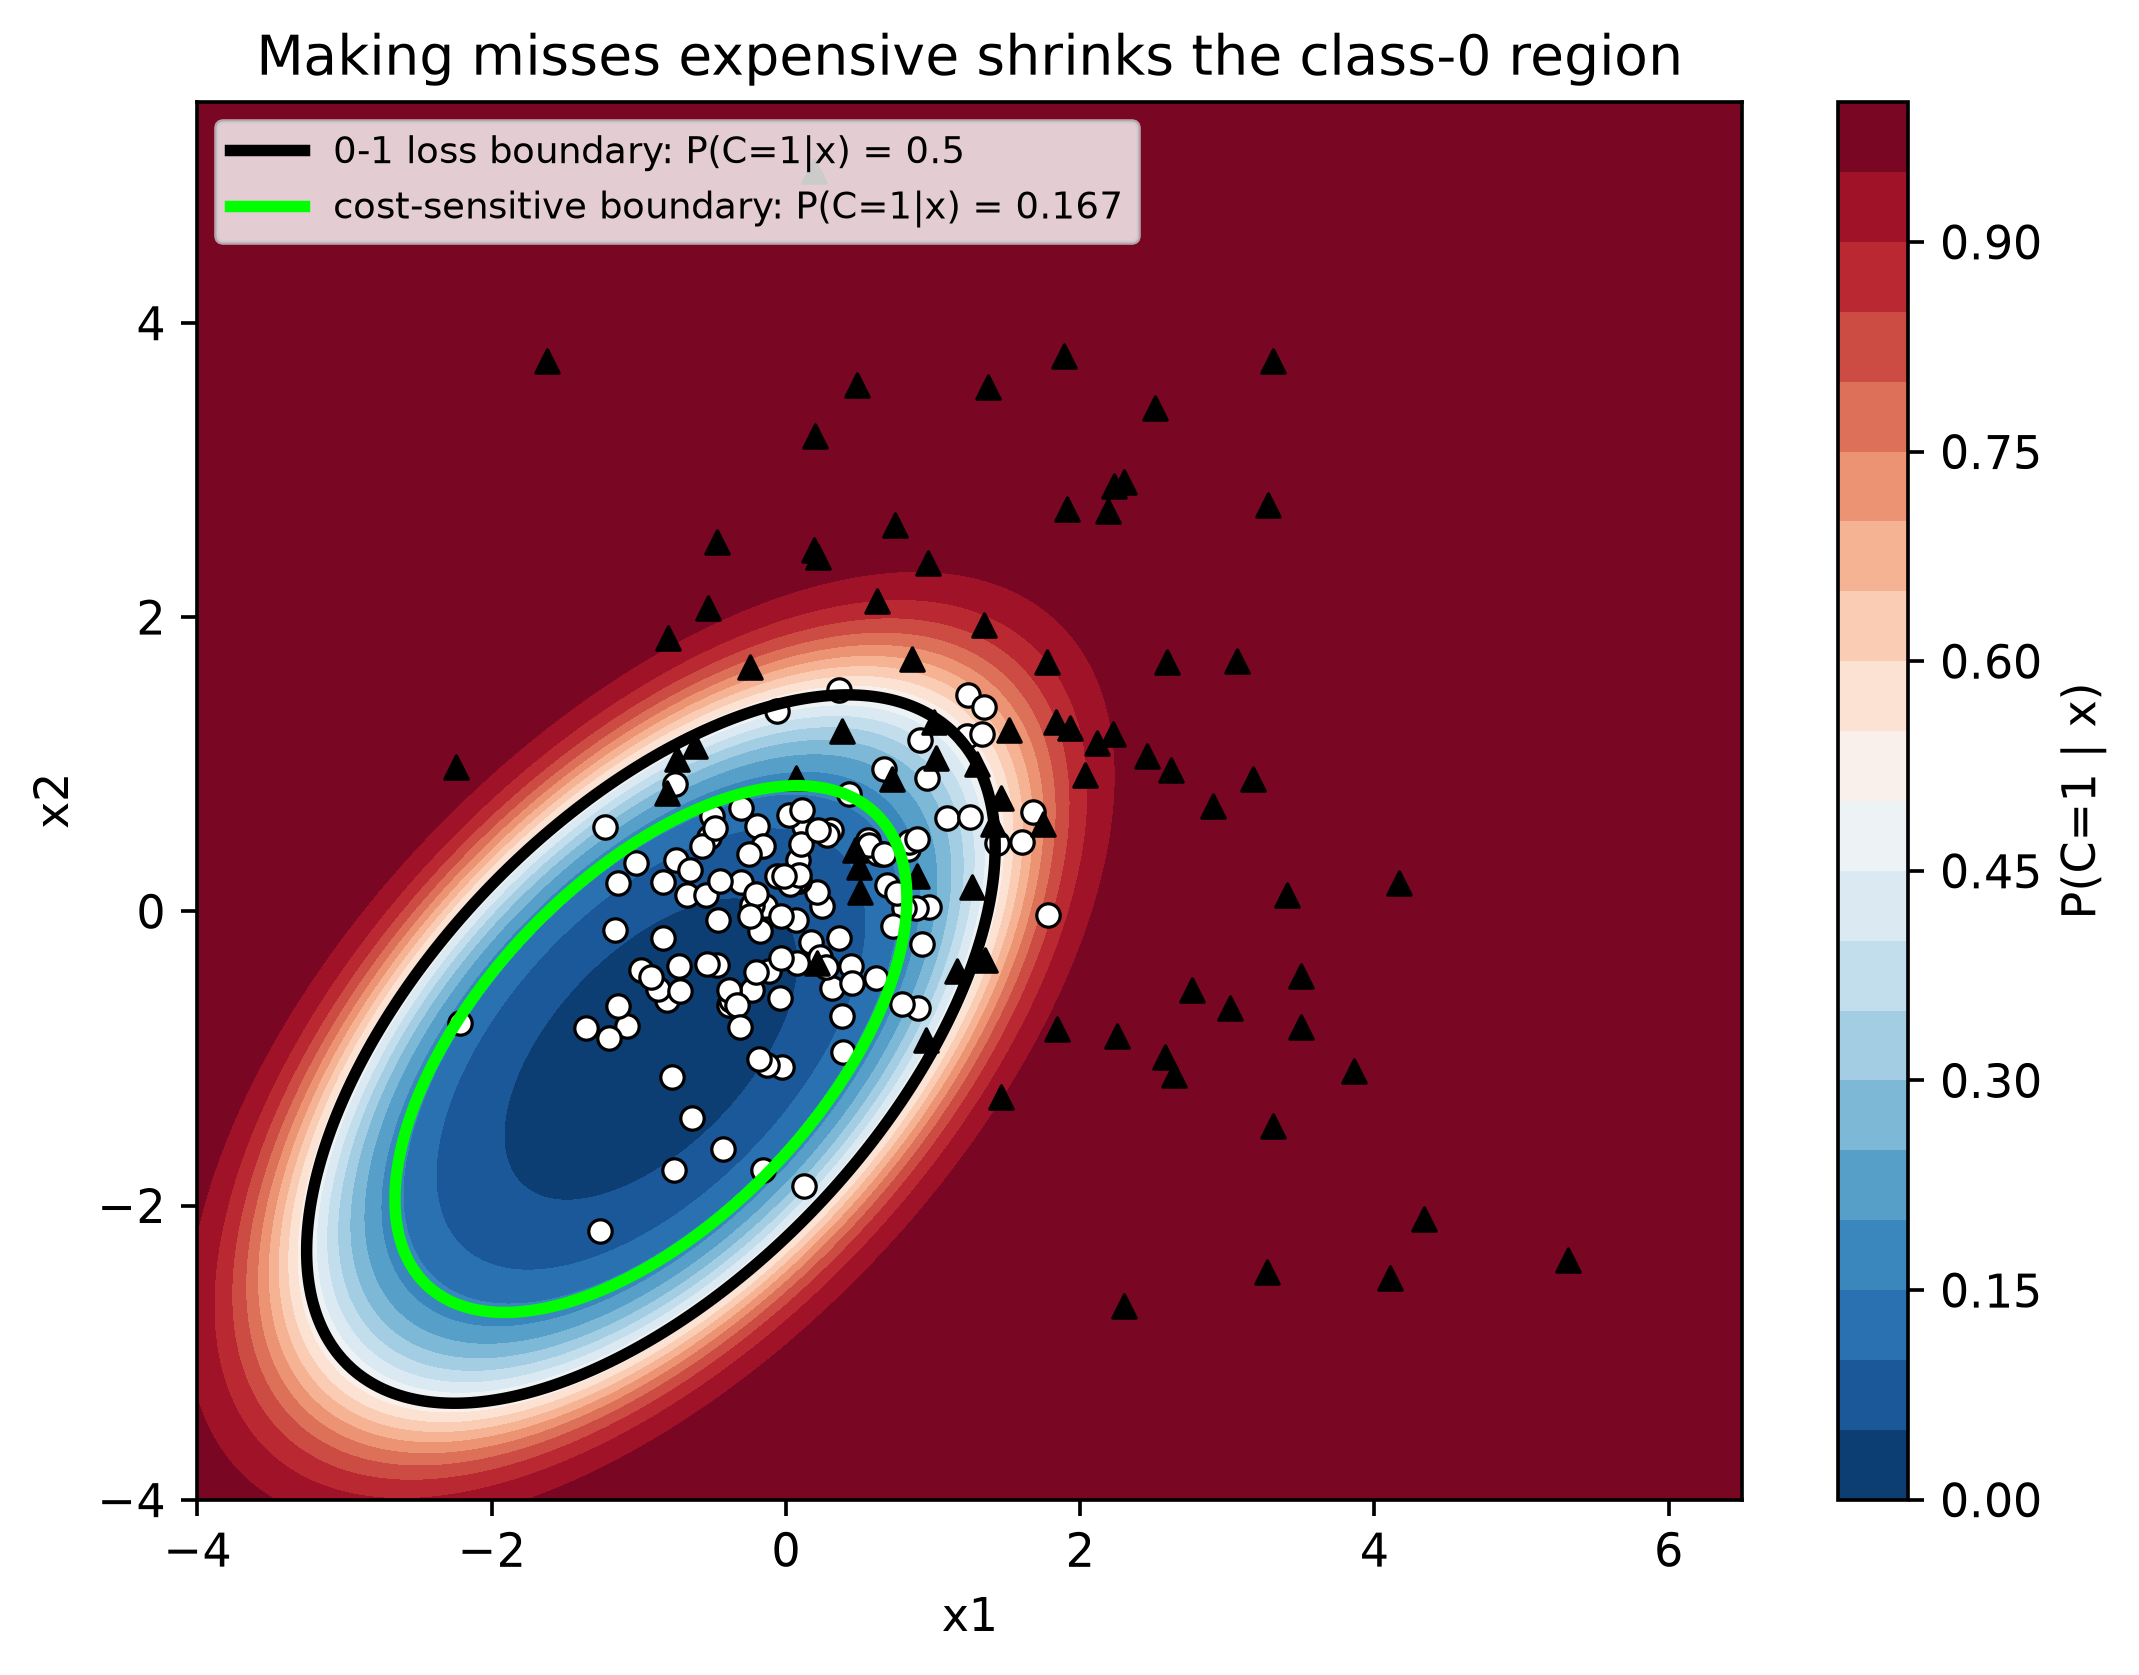

points sent to class 1 by the 0-1 rule            : 17667
points sent to class 1 by the cost-sensitive rule : 26040


In [32]:
def cost_sensitive_classifier(X, threshold=threshold_cost, priors=PRIORS, means=MEANS, covs=COVS):
    '''Bayes rule under a cost matrix: decide class 1 when P(C=1 | x) exceeds the threshold.'''
    posterior = scores_to_posterior(gaussian_class_scores(X, priors, means, covs))   # (n, 2)
    return (posterior[:, 1] > threshold).astype(int)                                 # compare with the threshold


pred_cost_test = cost_sensitive_classifier(X_test)                  # decisions on the 50 000 test points

fig, ax = plt.subplots(figsize=(7.5, 5.5))
filled = ax.contourf(P1, P2, post_grid, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
ax.contour(P1, P2, post_grid, levels=[0.5], colors="black", linewidths=2.5)          # 0-1 loss boundary
ax.contour(P1, P2, post_grid, levels=[threshold_cost], colors="lime", linewidths=2.5) # cost-sensitive boundary

for c, marker in ((0, "o"), (1, "^")):
    keep = y_train == c
    ax.scatter(X_train[keep, 0], X_train[keep, 1], marker=marker,
               facecolor="white" if c == 0 else "black", edgecolor="black", s=26, linewidth=0.7)

ax.plot([], [], color="black", lw=2.5, label="0-1 loss boundary: P(C=1|x) = 0.5")
ax.plot([], [], color="lime", lw=2.5, label=f"cost-sensitive boundary: P(C=1|x) = {threshold_cost:.3f}")
ax.set_xlim(plot_g1[0], plot_g1[-1])
ax.set_ylim(plot_g2[0], plot_g2[-1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Making misses expensive shrinks the class-0 region")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
plt.colorbar(filled, ax=ax, label="P(C=1 | x)", fraction=0.04)
plt.show()

print("points sent to class 1 by the 0-1 rule            :", int(pred_bayes_test.sum()))
print("points sent to class 1 by the cost-sensitive rule :", int(pred_cost_test.sum()))

**Line by line**

- `cost_sensitive_classifier` : the posterior is computed exactly as before, and the only change is the last
  line. Instead of `argmax`, which is a comparison against 0.5, we compare against our own threshold. Notice
  that the *model* has not changed at all: same prior, same likelihoods, same posterior. **Only the decision
  changed.**
- `(posterior[:, 1] > threshold).astype(int)` : `posterior[:, 1]` is $P(C=1 \mid x)$ for every row; the
  comparison gives booleans, and `astype(int)` turns them into 0s and 1s.
- `ax.contour(..., levels=[threshold_cost], colors="lime")` : the second contour line. Drawing both on the same
  posterior surface makes the point that the surface is shared and the two rules simply cut it at different
  heights.
- `ax.plot([], [], ...)` : empty plots used only to create legend entries, since contour lines do not appear in
  a legend by themselves.
- `pred_bayes_test.sum()` : with labels 0 and 1, the sum counts how many points were sent to class 1.

**Reading the plot.** The green contour sits **inside** the black one, so the class-0 region has shrunk. Points
in the ring between the two contours have a posterior between 1/6 and 1/2: they are *probably* class 0, but not
probably enough. Since calling them class 0 risks a cost of 5 and calling them class 1 risks only 1, the
cost-sensitive rule hands them to class 1. The count confirms it: the number of points sent to class 1 rises
substantially.

**A useful way to say this.** The cost-sensitive rule behaves as though class 1 were more common than it really
is. Multiplying the prior of class 1 by 5 would produce exactly the same boundary, which is why rebalancing
priors and rebalancing costs are two ways of doing the same thing.

## Step 4: Each rule wins on its own loss

In [33]:
def rule_report(name, predictions):
    '''Error rate, average cost and the two kinds of mistake for one set of decisions.'''
    misses = int(np.sum((y_test == 1) & (predictions == 0)))       # truth 1, we said 0: the expensive mistake
    false_alarms = int(np.sum((y_test == 0) & (predictions == 1))) # truth 0, we said 1: the cheap mistake
    return {
        "rule": name,
        "error rate (0-1 loss)": np.mean(predictions != y_test),
        "average cost": LOSS_COST[y_test, predictions].mean(),     # fancy indexing: one cost per test point
        "misses (truth 1, said 0)": misses,
        "false alarms (truth 0, said 1)": false_alarms,
    }


report = pd.DataFrame([
    rule_report("0-1 Bayes rule (threshold 0.5)", pred_bayes_test),
    rule_report(f"cost-sensitive rule (threshold {threshold_cost:.3f})", pred_cost_test),
]).set_index("rule")

print(report.to_string())

print(f"\nthe 0-1 rule has the LOWER error rate   : "
      f"{report['error rate (0-1 loss)'].idxmin() == '0-1 Bayes rule (threshold 0.5)'}")
print(f"the cost-sensitive rule has the LOWER cost: "
      f"{report['average cost'].idxmin() != '0-1 Bayes rule (threshold 0.5)'}")

                                       error rate (0-1 loss)  average cost  misses (truth 1, said 0)  false alarms (truth 0, said 1)
rule                                                                                                                                
0-1 Bayes rule (threshold 0.5)                        0.1179        0.4525                      4182                            1714
cost-sensitive rule (threshold 0.167)                 0.1881        0.3281                      1750                            7655

the 0-1 rule has the LOWER error rate   : True
the cost-sensitive rule has the LOWER cost: True


**Line by line**

- `(y_test == 1) & (predictions == 0)` : two boolean arrays combined with `&` (elementwise AND), so this is
  `True` only for the expensive mistakes. `np.sum` counts them.
- `LOSS_COST[y_test, predictions]` : **fancy indexing with two arrays**, and the neatest line in this exercise.
  For every test point `i` it reads `LOSS_COST[y_test[i], predictions[i]]`, which is the cost actually incurred
  on that point. The result is an array of 50 000 costs, and its mean is the average cost of the rule. Writing
  a loop over 50 000 points would give the same answer far more slowly.
- `report['average cost'].idxmin()` : the row label with the smallest average cost.
- `.to_string()` : prints the whole table without pandas truncating the wide columns.

**Reading the table.**

- The **0-1 Bayes rule** has the lower error rate. It has to: it is the optimal rule for that loss, and we
  proved as much in Part 1 of the practical.
- The **cost-sensitive rule** has the lower average cost, roughly a quarter lower. It also has to: it is the
  optimal rule for that loss.
- The mechanism is visible in the last two columns. The cost-sensitive rule cuts the number of expensive misses
  by a large factor, and pays for that by making many more cheap false alarms. In total it makes *more*
  mistakes but *cheaper* mistakes.

**This is the heart of the exercise.** There is no single "best classifier" for a dataset. There is a best
classifier for a **loss**. Quoting an error rate without saying what the mistakes cost hides the choice rather
than avoiding it.

## Step 5: A situation where you would accept the higher error rate

Any answer along these lines is fine. A worked example:

> **Screening for a treatable disease.** A hospital screens patients with a cheap blood test. Deciding "no
> disease" for a patient who has it means the disease is found months later, when treatment is harder, far more
> expensive and less likely to work. Deciding "disease" for a healthy patient means one extra confirmatory test:
> some anxiety, some money, no lasting harm. If a miss is 5 to 50 times worse than a false alarm, the screening
> threshold should be set well below 0.5, and the resulting rule will have a *higher* overall error rate than
> the 0-1 optimal rule. That is the right trade, and it is why real screening programmes are deliberately tuned
> to over-refer.

Other good examples: fraud detection (a missed fraud costs the bank the whole transaction, a false alarm costs
one phone call), predictive maintenance on aircraft parts, spam filtering with the costs the other way round (a
legitimate email in the spam folder is usually worse than a spam email in the inbox, so there the threshold moves
in the opposite direction).

**What to take away from Exercise 1**

1. The posterior $P(c \mid x)$ is the output of the *model*. The threshold applied to it is the output of the
   *loss function*. They are separate decisions and can be changed independently.
2. You can re-tune a deployed classifier for a new cost structure without retraining anything, just by moving the
   threshold.
3. Error rate and average cost rank classifiers differently, so you must decide which one you are optimising
   before you compare models.

---
# Exercise 2: When is a straight line good enough?

**The question.** Logistic regression lost badly in Part 3 because the Bayes boundary was an ellipse. Build a
world in which both classes share one covariance matrix, and find out what happens.

## Step 1: A world with a shared covariance matrix

In [34]:
COV_SHARED = np.array([[1.0, 0.3],                 # one covariance matrix ...
                       [0.3, 1.0]])
COVS_EQ = [COV_SHARED, COV_SHARED]                 # ... used by BOTH classes

X_train_eq, y_train_eq = sample_world(200, covs=COVS_EQ)        # training set from the new world
X_test_eq, y_test_eq = sample_world(50_000, covs=COVS_EQ)       # test set from the new world

print("training set:", X_train_eq.shape, " class counts:", np.bincount(y_train_eq))
print("test set    :", X_test_eq.shape, " class counts:", np.bincount(y_test_eq))
print("\nthe two classes now have identical shapes:")
print("cov of class 0 =\n", COVS_EQ[0])
print("cov of class 1 =\n", COVS_EQ[1])

training set: (200, 2)  class counts: [117  83]
test set    : (50000, 2)  class counts: [30078 19922]

the two classes now have identical shapes:
cov of class 0 =
 [[1.  0.3]
 [0.3 1. ]]
cov of class 1 =
 [[1.  0.3]
 [0.3 1. ]]


**Line by line**

- `COVS_EQ = [COV_SHARED, COV_SHARED]` : the same array object is placed in both slots of the list. Both classes
  therefore have exactly the same spread and the same tilt; only their centres differ.
- `sample_world(200, covs=COVS_EQ)` : the default arguments of `sample_world` are used for the prior and the
  means, and only `covs` is replaced. That is why the function was written with defaults in the practical.
- The prior and the means are unchanged from Part 3, so the only difference between this world and the old one
  is the shape of the clouds.

## Step 2: The Bayes boundary is now a straight line

**Why.** The Bayes rule compares the two log scores. Their difference is

$$\log\frac{P(1)p(x \mid 1)}{P(0)p(x \mid 0)} = \log\frac{P(1)}{P(0)} - \tfrac{1}{2}\Big[(x-\mu_1)^\top \Sigma_1^{-1}(x-\mu_1) - (x-\mu_0)^\top \Sigma_0^{-1}(x-\mu_0)\Big] - \tfrac{1}{2}\log\frac{|\Sigma_1|}{|\Sigma_0|}$$

Expand the two quadratic forms. Each of them contains a term in $x^\top \Sigma_c^{-1} x$, a term linear in $x$
and a constant.

* When $\Sigma_0 \neq \Sigma_1$, the two quadratic terms $x^\top \Sigma_1^{-1} x$ and $x^\top \Sigma_0^{-1} x$ are
  different, they do not cancel, and the set of $x$ where the difference is zero is a **quadratic curve**: an
  ellipse, a parabola or a hyperbola. That is the closed ellipse we saw in Part 3.
* When $\Sigma_0 = \Sigma_1 = \Sigma$, the two quadratic terms are **identical** and cancel exactly. So does the
  log-determinant term. What survives is linear in $x$:

$$\log\frac{P(1)}{P(0)} + x^\top \Sigma^{-1}(\mu_1 - \mu_0) - \tfrac{1}{2}(\mu_1 + \mu_0)^\top \Sigma^{-1}(\mu_1 - \mu_0)$$

Setting a linear expression to zero gives a **straight line** (a hyperplane in higher dimensions). This is why
the method is called *linear* discriminant analysis when the covariances are shared and *quadratic* discriminant
analysis when they are not.

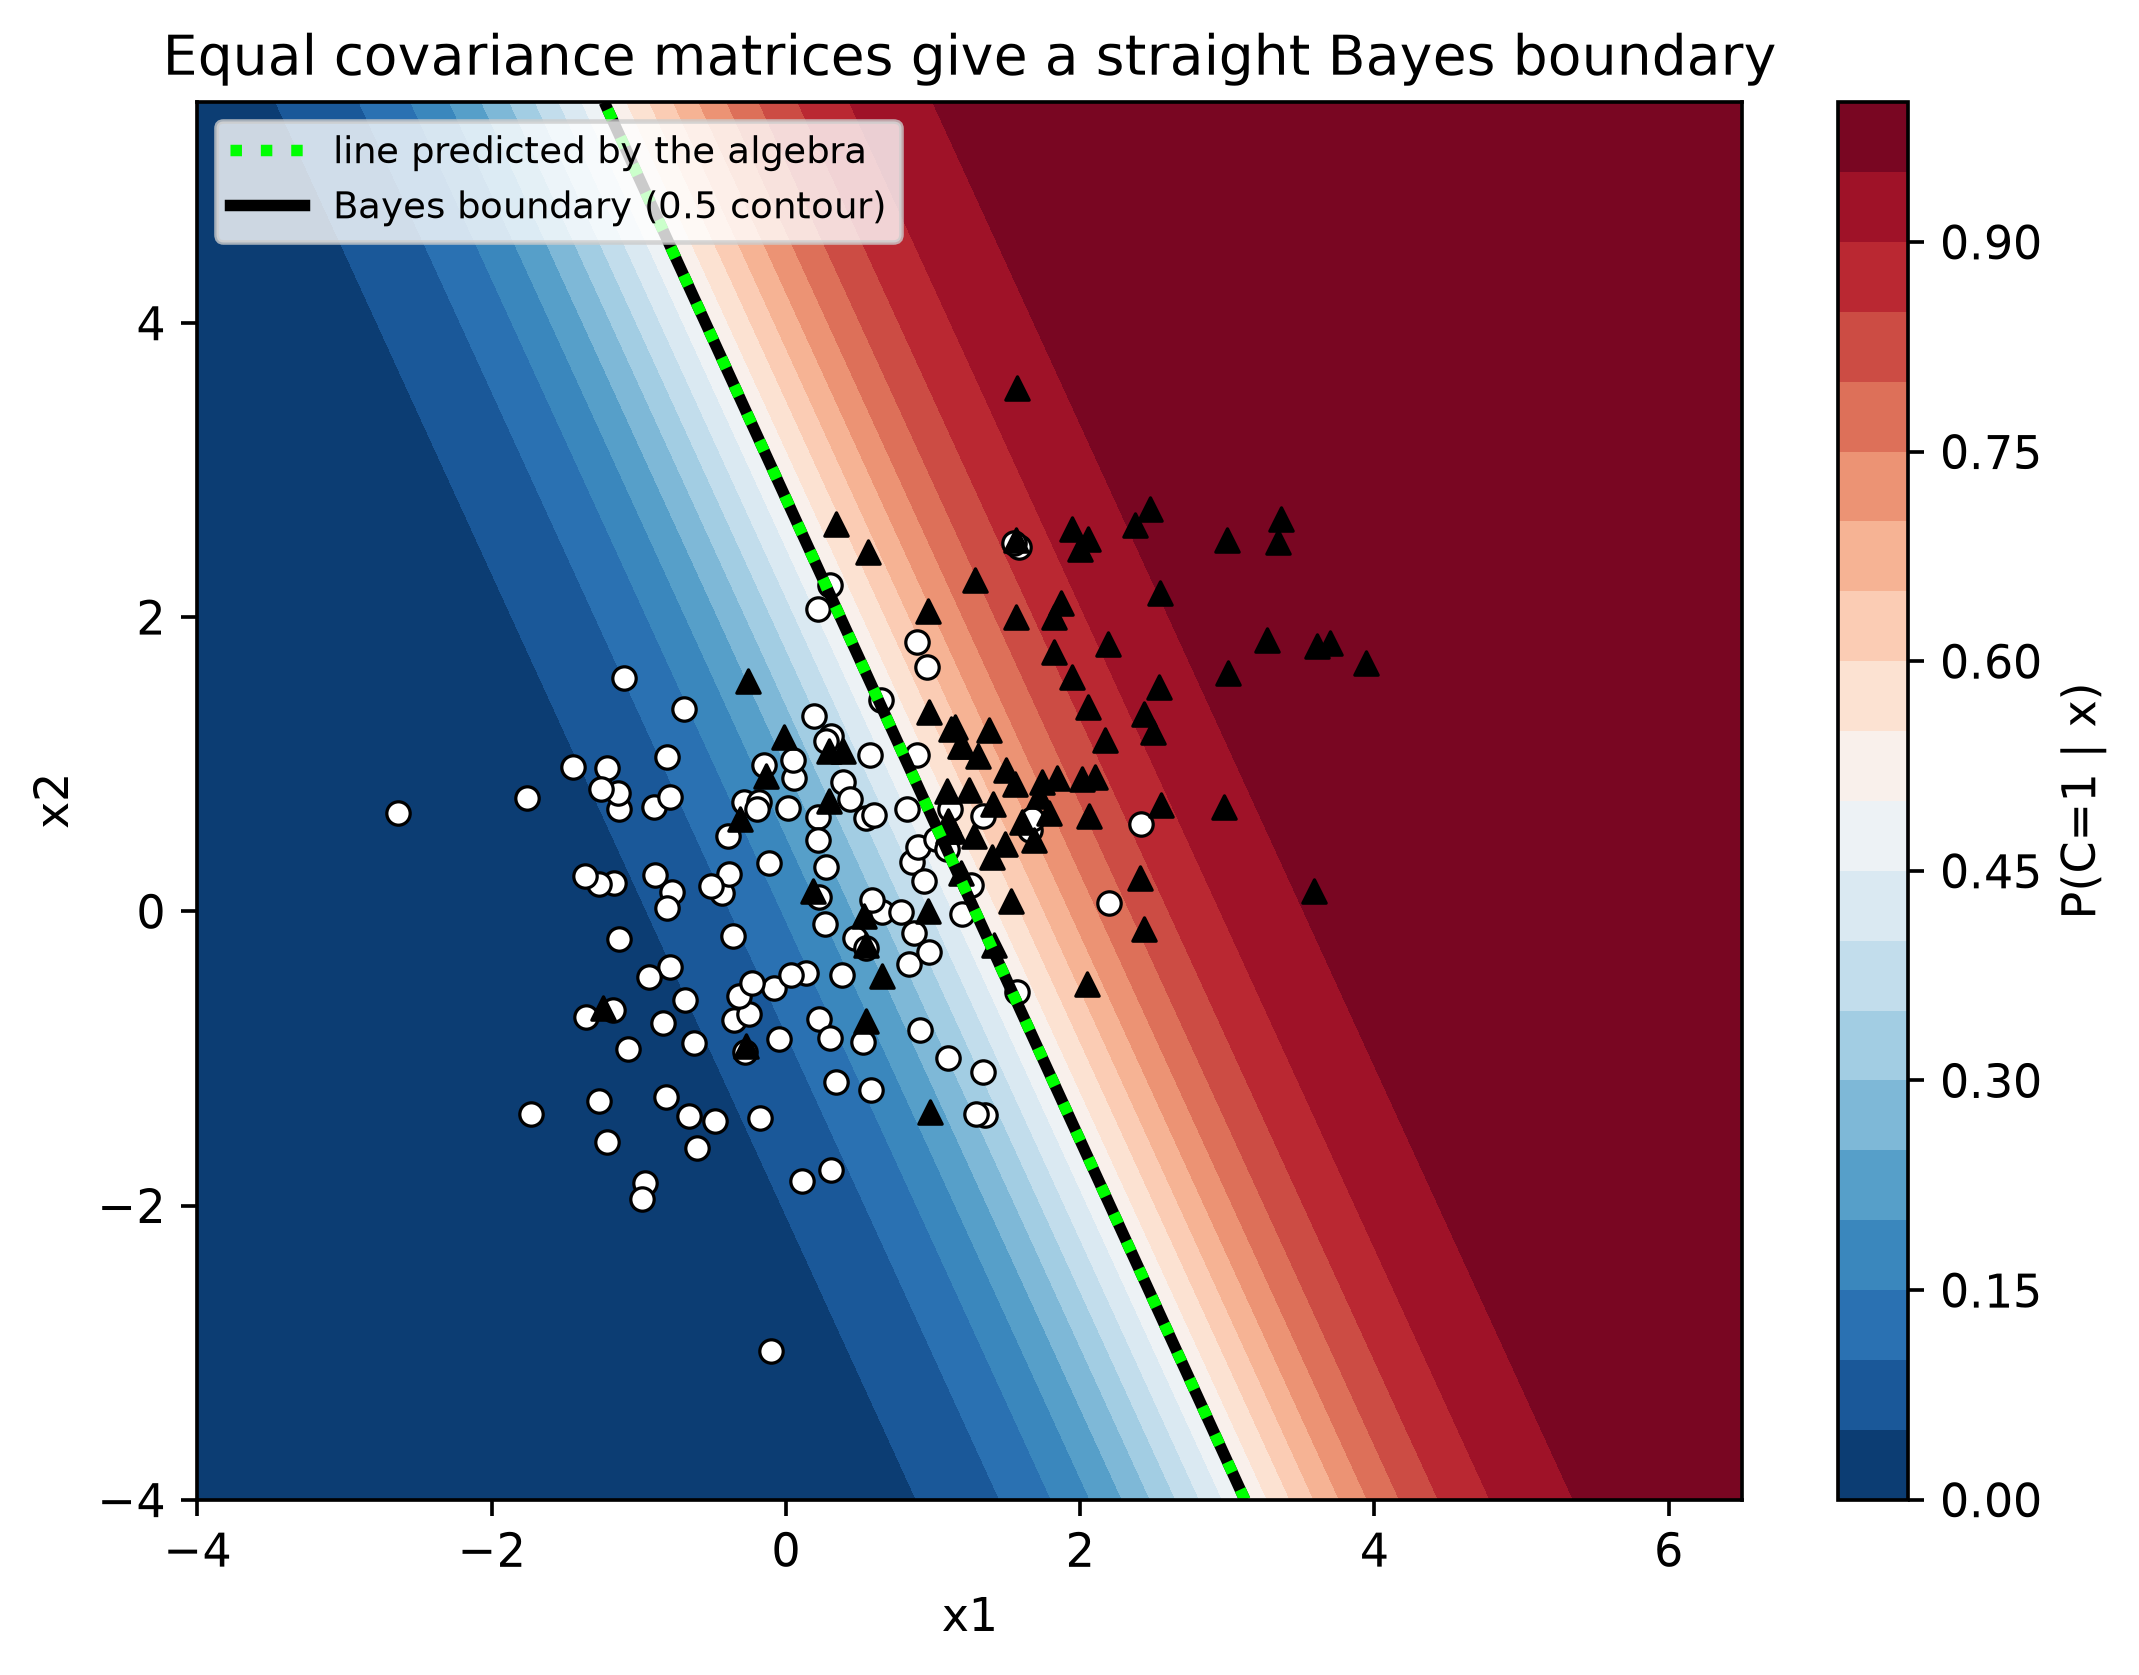

In [35]:
post_grid_eq = scores_to_posterior(
    gaussian_class_scores(plot_points, PRIORS, MEANS, COVS_EQ))[:, 1].reshape(P1.shape)

# the boundary predicted by the algebra above: log(P1/P0) + x.w + b = 0
w_linear = np.linalg.inv(COV_SHARED) @ (MEANS[1] - MEANS[0])                      # the direction of the line
b_linear = (-0.5 * (MEANS[1] + MEANS[0]) @ w_linear                               # the offset ...
            + np.log(PRIORS[1] / PRIORS[0]))                                      # ... including the prior term

line_x1 = np.linspace(plot_g1[0], plot_g1[-1], 200)                               # x1 values along the line
line_x2 = -(w_linear[0] * line_x1 + b_linear) / w_linear[1]                       # solve w.x + b = 0 for x2

fig, ax = plt.subplots(figsize=(7.5, 5.5))
filled = ax.contourf(P1, P2, post_grid_eq, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
ax.contour(P1, P2, post_grid_eq, levels=[0.5], colors="black", linewidths=2.5)
ax.plot(line_x1, line_x2, color="lime", ls=":", lw=2.5, label="line predicted by the algebra")

for c, marker in ((0, "o"), (1, "^")):
    keep = y_train_eq == c
    ax.scatter(X_train_eq[keep, 0], X_train_eq[keep, 1], marker=marker,
               facecolor="white" if c == 0 else "black", edgecolor="black", s=26, linewidth=0.7)

ax.plot([], [], color="black", lw=2.5, label="Bayes boundary (0.5 contour)")
ax.set_xlim(plot_g1[0], plot_g1[-1])
ax.set_ylim(plot_g2[0], plot_g2[-1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Equal covariance matrices give a straight Bayes boundary")
ax.set_aspect("equal")
ax.legend(fontsize=8, loc="upper left")
plt.colorbar(filled, ax=ax, label="P(C=1 | x)", fraction=0.04)
plt.show()

**Line by line**

- `post_grid_eq` : the true posterior of the **new** world on the plotting grid, computed exactly as in the
  practical but with `COVS_EQ`.
- `w_linear = inv(COV_SHARED) @ (MEANS[1] - MEANS[0])` : the direction vector $\Sigma^{-1}(\mu_1 - \mu_0)$ from
  the formula. Note it is not simply the direction from one mean to the other; the inverse covariance rotates it,
  because a step across a narrow direction of the clouds is more informative than a step along a wide one.
- `b_linear` : the constant term, the midpoint correction plus the prior term $\log(P(1)/P(0))$.
- `line_x2 = -(w_linear[0] * line_x1 + b_linear) / w_linear[1]` : the equation $w_1x_1 + w_2x_2 + b = 0$
  rearranged for $x_2$. Plotting this alongside the contour is an independent check of the algebra.
- The green dotted line lies exactly on top of the black contour, so the derivation and the numerical posterior
  agree.

**Reading the plot.** The boundary is perfectly straight, and the posterior now changes along parallel bands
rather than concentric ellipses. The whole geometry of the problem has become linear, and this is the situation
a linear model was designed for.

## Step 3: The Bayes error rate of the new world

In [36]:
bayes_err_eq = bayes_error_by_integration(PRIORS, MEANS, COVS_EQ)         # by integration
pred_bayes_eq = bayes_classifier(X_test_eq, covs=COVS_EQ)                 # the Bayes decisions
bayes_err_eq_counted = np.mean(pred_bayes_eq != y_test_eq)                # by counting mistakes
se_eq = np.sqrt(bayes_err_eq_counted * (1 - bayes_err_eq_counted) / len(y_test_eq))

print(f"Bayes error rate by integration : {bayes_err_eq:.4f}")
print(f"Bayes error rate by counting    : {bayes_err_eq_counted:.4f}   (+/- {se_eq:.4f})")
print(f"\nfor comparison, the Part 3 world (different covariances): {BAYES_ERROR:.4f}")

Bayes error rate by integration : 0.2036
Bayes error rate by counting    : 0.2012   (+/- 0.0018)

for comparison, the Part 3 world (different covariances): 0.1171


**Line by line**

- `bayes_classifier(X_test_eq, covs=COVS_EQ)` : again only the `covs` argument changes. Forgetting to pass it
  would classify the new data with the old world's parameters, which is a quiet and very common bug: the code
  would run and give plausible but wrong numbers.
- The standard error tells us how much the counted value can wobble, so we know whether a difference of 0.001 is
  meaningful.

**Reading the output.** The two methods agree. This world has a Bayes error rate of about 0.204, noticeably
**higher** than the 0.117 of the Part 3 world. That is worth a moment's thought: we made the world simpler for a
linear model, but not easier overall. Class 0 used to be a tight cloud that was easy to separate from the wide
class 1. Now both clouds have the same middling spread and overlap more, so more points are genuinely ambiguous.
**A lower Bayes error rate means a more separable world, not a simpler boundary shape.**

## Step 4: The three classifiers in the new world

In [37]:
params_hat_eq = fit_plugin_gaussian(X_train_eq, y_train_eq)           # plug-in Gaussian on the new training set
logistic_eq = fit_logistic(X_train_eq, y_train_eq.astype(float))      # logistic regression on the new training set

classifiers_eq = {
    "Bayes classifier (true parameters)": lambda X: bayes_classifier(X, covs=COVS_EQ),
    "plug-in Gaussian (QDA)":             lambda X: gaussian_class_scores(X, *params_hat_eq).argmax(axis=1),
    "logistic regression":                lambda X: predict_logistic(X, logistic_eq),
    "k-NN, k = 15":                       lambda X: knn_predict(X_train_eq, y_train_eq, X, k=15),
}

rows = []
for name, predict in classifiers_eq.items():
    test_err = np.mean(predict(X_test_eq) != y_test_eq)
    rows.append({"classifier": name,
                 "train error": np.mean(predict(X_train_eq) != y_train_eq),
                 "test error": test_err,
                 "excess over exact R*": test_err - bayes_err_eq,              # R* from integration
                 "excess over Bayes on this test set": test_err - bayes_err_eq_counted})

comparison_eq = pd.DataFrame(rows).set_index("classifier")
print(f"Bayes error rate of the new world: {bayes_err_eq:.4f}\n")
print(comparison_eq.to_string())

Bayes error rate of the new world: 0.2036

                                    train error  test error  excess over exact R*  excess over Bayes on this test set
classifier                                                                                                           
Bayes classifier (true parameters)        0.160      0.2012               -0.0024                              0.0000
plug-in Gaussian (QDA)                    0.165      0.2029               -0.0007                              0.0017
logistic regression                       0.160      0.2014               -0.0023                              0.0001
k-NN, k = 15                              0.155      0.2055                0.0019                              0.0043


**Line by line**

- The dictionary of `lambda` functions is the same pattern as Part 3f, so one loop can evaluate every
  classifier. Each lambda captures the models fitted on the **new** training set.
- `gaussian_class_scores(X, *params_hat_eq)` : the `*` unpacks the estimated prior, means and covariances into
  three arguments.
- `predict(X_train_eq)` and `predict(X_test_eq)` : the same function applied to the data it learned from and to
  fresh data.

**A word on the two excess columns.** The exact Bayes error rate of this world is 0.2036, but the Bayes
classifier scores 0.2012 on this particular test set: with 50 000 points the standard error is about 0.0018, so
a gap of that size is ordinary sampling noise. Measuring excess against the exact value therefore produces small
negative numbers, which look alarming and mean nothing. The fairest comparison is the last column, where every
classifier is compared with the Bayes classifier **on the same test points**, so the noise largely cancels. Read
that column and the ranking is clean: nothing is negative, and nothing beats the Bayes classifier.

**Reading the table.** Logistic regression's excess error has collapsed from about 0.059 in Part 3 to about
0.0001 here. It is now indistinguishable from the Bayes classifier.

The explanation uses the two words from Part 3h.

* **Approximation error** is the part of the excess caused by the model family being unable to represent the
  Bayes boundary. In Part 3 the Bayes boundary was an ellipse and logistic regression could only draw lines, so
  this term was large and no amount of data could remove it. Here the Bayes boundary **is** a line, so logistic
  regression's approximation error is zero.
* **Estimation error** is the part caused by having only 200 training points. Every trained classifier here pays
  it, and the last column ranks them by how much. Logistic regression pays least, about 0.0001, because it
  estimates only 3 numbers. The plug-in Gaussian pays about 0.0017: it estimates 11 numbers, including two full
  covariance matrices which we know are identical but it does not, so it wastes data learning a difference that
  is not there. k-NN with $k=15$ pays about 0.0043, the most, because it assumes nothing at all and has to learn
  the shape of the boundary from the points themselves.

**The lesson is not "logistic regression is good".** It is that a model family which matches the truth needs
less data, and a model family which does not match the truth cannot be rescued by data. In Part 3 the plug-in
Gaussian was the well-matched model; here logistic regression is. Neither is universally better.

## Step 5: How the Bayes error rate depends on how far apart the classes are

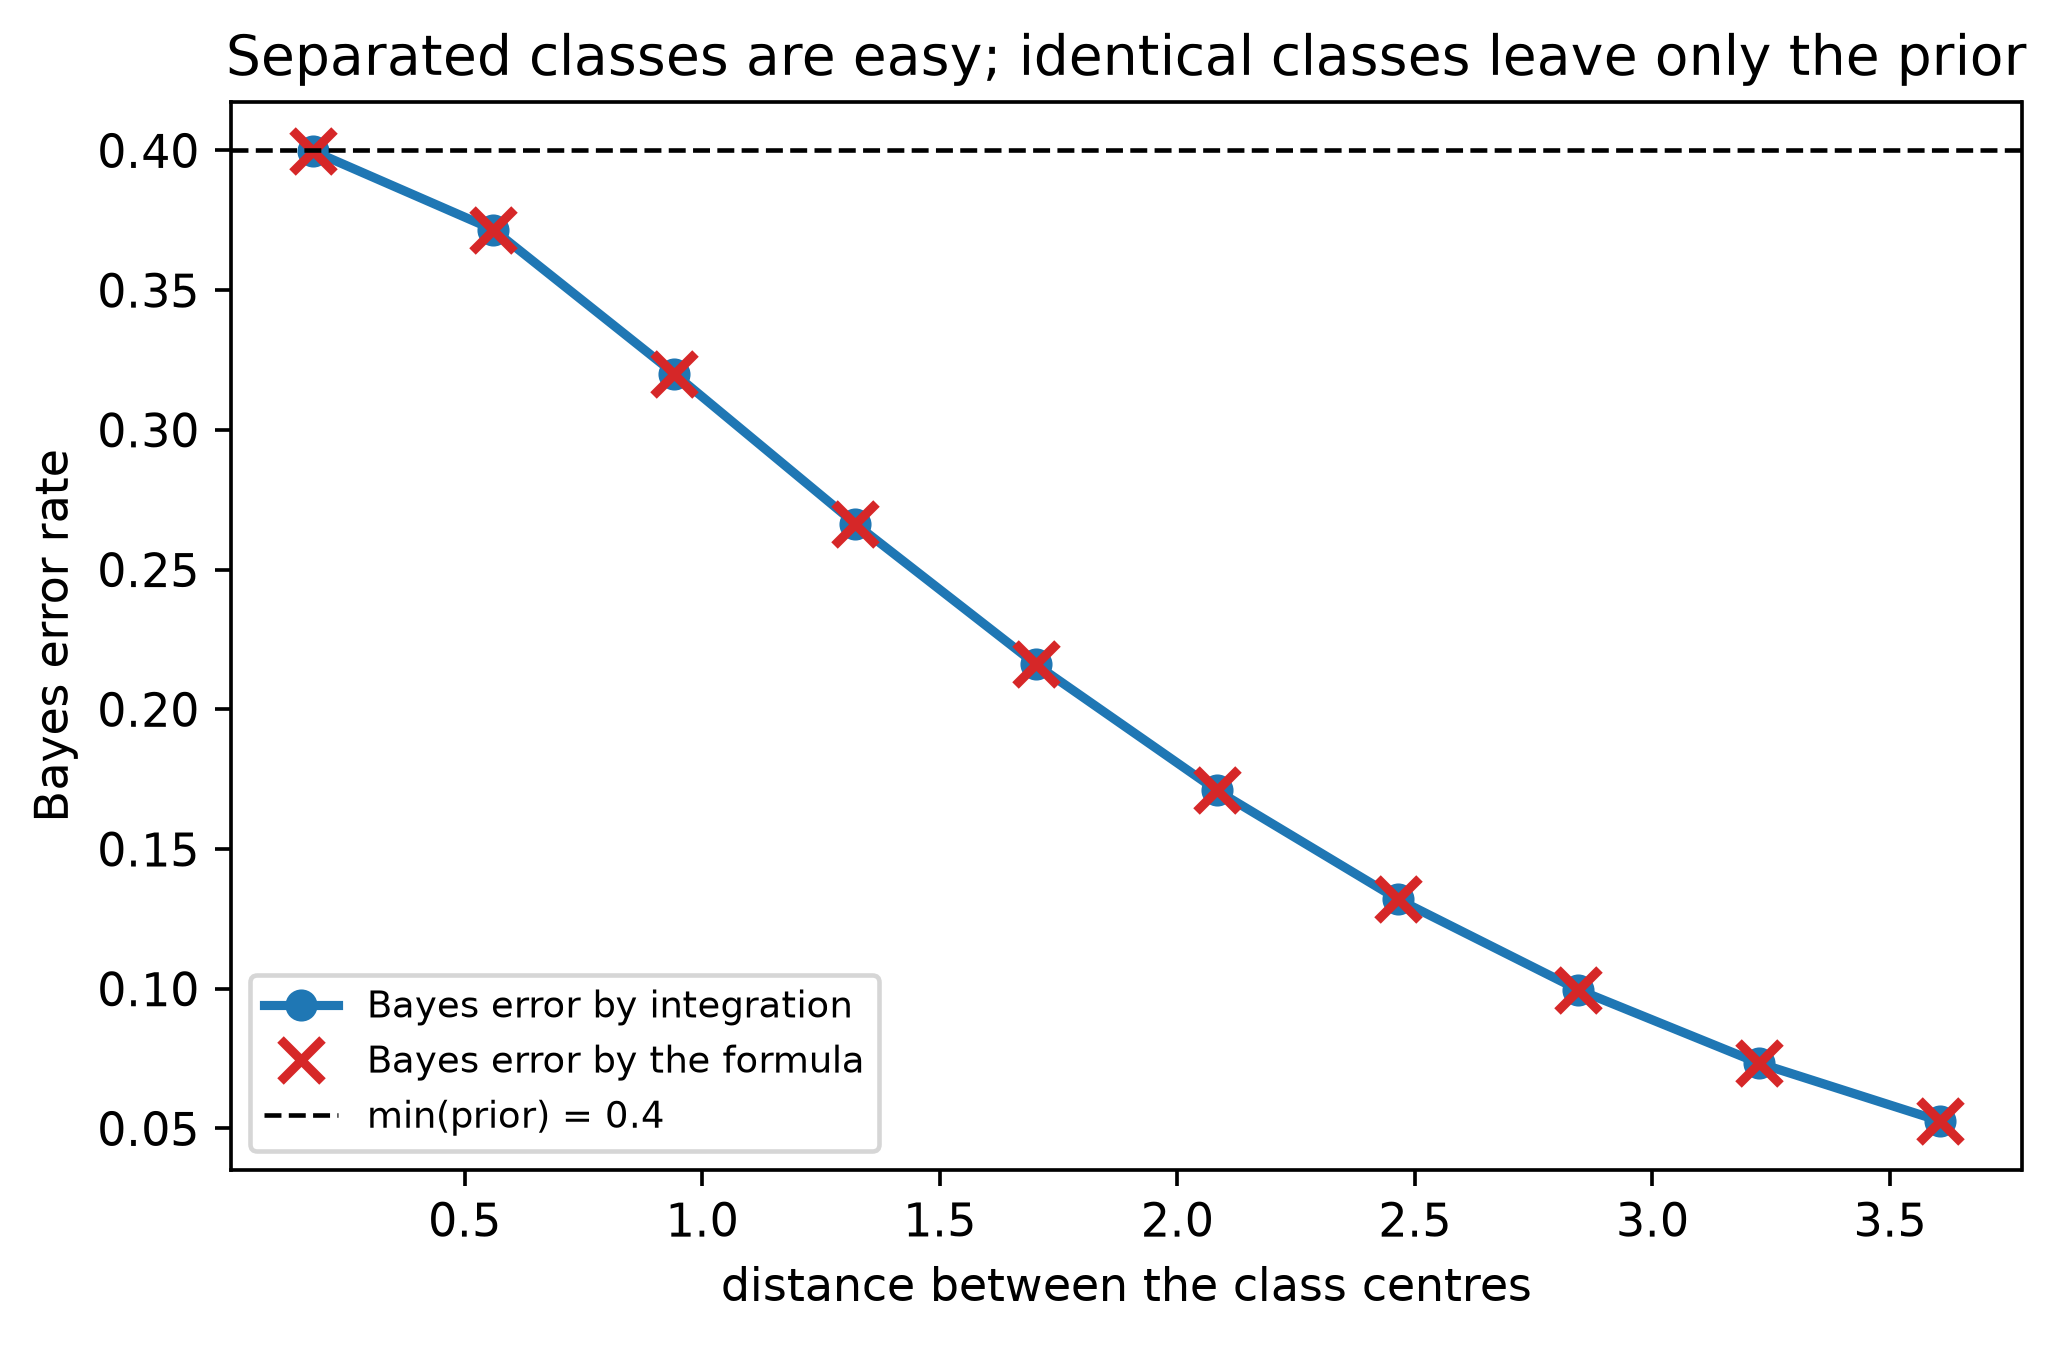

 distance  Bayes error (integration)  Bayes error (formula)
    0.180                     0.3999                 0.3999
    0.561                     0.3717                 0.3717
    0.941                     0.3201                 0.3201
    1.322                     0.2665                 0.2665
    1.703                     0.2161                 0.2161
    2.083                     0.1710                 0.1710
    2.464                     0.1321                 0.1321
    2.844                     0.0996                 0.0996
    3.225                     0.0733                 0.0733
    3.606                     0.0527                 0.0527


In [38]:
def normal_cdf(z):
    '''Standard normal CDF, written with the error function so that no library beyond math is needed.'''
    return 0.5 * (1.0 + np.vectorize(math.erf)(z / np.sqrt(2.0)))


steps = np.linspace(0.05, 1.0, 10)                        # how far along the direction (3, 2) class 1 sits
distances, errors_integral, errors_formula = [], [], []

cov_inv_shared = np.linalg.inv(COV_SHARED)

for t in steps:
    mu1 = t * np.array([3.0, 2.0])                                     # the moving class-1 centre
    means_t = [np.array([0.0, 0.0]), mu1]
    distances.append(np.linalg.norm(mu1))                              # ordinary distance between the centres
    errors_integral.append(bayes_error_by_integration(PRIORS, means_t, COVS_EQ))

    delta = np.sqrt(mu1 @ cov_inv_shared @ mu1)                        # Mahalanobis distance between the classes
    log_ratio = np.log(PRIORS[1] / PRIORS[0])
    errors_formula.append(PRIORS[0] * normal_cdf(-delta / 2 + log_ratio / delta)
                          + PRIORS[1] * normal_cdf(-delta / 2 - log_ratio / delta))

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(distances, errors_integral, "o-", color="tab:blue", lw=2, label="Bayes error by integration")
ax.plot(distances, errors_formula, "x", color="tab:red", ms=9, mew=2, label="Bayes error by the formula")
ax.axhline(PRIORS.min(), color="black", ls="--", lw=1, label=f"min(prior) = {PRIORS.min()}")
ax.set_xlabel("distance between the class centres")
ax.set_ylabel("Bayes error rate")
ax.set_title("Separated classes are easy; identical classes leave only the prior")
ax.legend(fontsize=8)
plt.show()

print(pd.DataFrame({"distance": np.round(distances, 3),
                    "Bayes error (integration)": np.round(errors_integral, 4),
                    "Bayes error (formula)": np.round(errors_formula, 4)}).to_string(index=False))

**Line by line**

- `normal_cdf` : the probability that a standard normal variable is below `z`. NumPy has no built-in normal CDF,
  so we use the error function from the `math` module, which is related to it by
  $\Phi(z) = \tfrac{1}{2}\big(1 + \operatorname{erf}(z/\sqrt{2})\big)$. `np.vectorize` wraps the scalar
  `math.erf` so that it also accepts arrays. (`np.vectorize` is a convenience, not a speed-up: it loops
  internally. With ten values that does not matter.)
- `t * np.array([3.0, 2.0])` : the class-1 centre moves along the straight path from the origin to $(3, 2)$ as
  `t` goes from 0.05 to 1.
- `np.linalg.norm(mu1)` : the ordinary (Euclidean) distance between the two centres, used for the x-axis.
- `delta = np.sqrt(mu1 @ cov_inv_shared @ mu1)` : the **Mahalanobis distance** between the two classes, which is
  the distance that actually matters. Two clouds 3 units apart are easy to separate if they are narrow and hard
  if they are wide, and $\Delta$ measures the separation in units of the clouds' own spread.
- The formula being checked, valid only when both classes share one covariance matrix, is

  $$R^* = P(0)\,\Phi\!\Big(-\tfrac{\Delta}{2} + \tfrac{1}{\Delta}\log\tfrac{P(1)}{P(0)}\Big) + P(1)\,\Phi\!\Big(-\tfrac{\Delta}{2} - \tfrac{1}{\Delta}\log\tfrac{P(1)}{P(0)}\Big)$$

  It comes from the fact that the linear score $w^\top x$ is Gaussian within each class, so each type of error is
  a tail probability of a one-dimensional Gaussian.
- The red crosses land on the blue curve, which is a strong check: a slow two-dimensional numerical integration
  and a one-line closed form agree.

**Reading the plot.**

- As the classes move apart the Bayes error rate falls steadily towards zero. Far apart means almost no overlap,
  and almost no overlap means almost no unavoidable mistakes.
- As the distance goes to zero the error rate rises towards **0.4**, which is `min(PRIORS)`. When the two classes
  sit exactly on top of each other the features carry no information whatsoever: $P(C=1 \mid x) = P(C=1) = 0.4$ at
  every $x$. The best possible rule is then to ignore $x$ and always answer with the more common class, which is
  wrong on the 40% of points belonging to the other one.
- So `min(prior)` is the worst a Bayes error rate can ever be in a two-class problem, and it is exactly the
  "always guess the majority class" baseline from Practical 2. **A classifier that scores near that baseline is
  not necessarily badly trained; it may be working in a world where the features simply do not carry the answer.**

**What to take away from Exercise 2**

1. Equal covariance matrices make the Bayes boundary linear, which is the assumption behind linear discriminant
   analysis and the reason logistic regression is so often good enough in practice.
2. Excess error splits into approximation error (wrong model family, unfixable by data) and estimation error
   (finite sample, fixable by data). Matching the family to the truth removes the first and shrinks the second.
3. The Bayes error rate measures the overlap of the classes, not the complexity of the boundary, and it is
   bounded above by `min(prior)`.

---
# Exercise 3: Bias and variance from a single dataset, using the bootstrap

**The question.** In Part 5 we drew 500 brand-new training sets from the world. In real life you get one dataset.
The bootstrap makes "new" datasets by resampling the one you have, with replacement. How well does that work?

Because a bootstrap resample of $(x, y)$ pairs imitates drawing a new dataset in which the inputs are random too,
this exercise uses `sample_regression`, which draws random $x$ values, rather than the fixed grid of Part 5.

## Steps 1 and 2: One dataset, and 400 bootstrap resamples of it

In [39]:
N_ONE = 100                                        # size of the single dataset we are given
B = 400                                            # number of bootstrap resamples
DEGREES_EX3 = list(range(0, 9))                    # degrees 0 to 8

x_one, y_one = sample_regression(N_ONE)            # THE dataset: in real life this is all you ever get


def bootstrap_variance(x_data, y_data, degrees, n_boot=B):
    '''Average variance of the fitted curves across bootstrap resamples of one dataset.'''
    n = len(x_data)
    out = []
    for degree in degrees:
        preds = np.empty((n_boot, len(X_EVAL)))                      # one fitted curve per resample
        for b in range(n_boot):
            idx = rng.choice(n, size=n, replace=True)                # n indices drawn WITH replacement
            w = fit_poly(x_data[idx], y_data[idx], degree)           # fit to the resampled dataset
            preds[b] = predict_poly(X_EVAL, w)                       # its predictions on the grid
        out.append(np.mean(preds.var(axis=0)))                       # variance across resamples, averaged over x
    return np.array(out)


boot_var = bootstrap_variance(x_one, y_one, DEGREES_EX3)

idx_demo = rng.choice(N_ONE, size=N_ONE, replace=True)               # one resample, just to look at it
print(f"dataset size                              : {N_ONE}")
print(f"distinct points in one bootstrap resample : {len(np.unique(idx_demo))}")
print(f"expected number of distinct points        : {N_ONE * (1 - (1 - 1 / N_ONE) ** N_ONE):.1f}")
print(f"\nbootstrap variance per degree: {boot_var.round(4)}")

dataset size                              : 100
distinct points in one bootstrap resample : 61
expected number of distinct points        : 63.4

bootstrap variance per degree: [0.0137 0.0172 0.0171 0.0118 0.0147 0.0164 0.0211 0.0276 0.0371]


**Line by line**

- `x_one, y_one = sample_regression(N_ONE)` : the one dataset we pretend to have been given. Everything in steps
  1 and 2 uses only this, never the world.
- `rng.choice(n, size=n, replace=True)` : the bootstrap itself, in one line. It draws `n` positions from
  `0 .. n-1` **with replacement**, so some indices appear twice or more and others not at all. `replace=True`
  is the entire difference between a bootstrap resample and a reshuffle.
- `x_data[idx], y_data[idx]` : indexing both arrays with the same index array keeps the pairs together. Using
  two different index arrays here would pair each $x$ with someone else's $y$ and destroy the relationship.
- `preds.var(axis=0)` : the variance down the rows, that is, across the 400 resamples, at each of the 201 grid
  points. `np.mean` of that is one number per degree, computed exactly as in `bias_variance_table`.
- `len(np.unique(idx_demo))` : how many distinct original points made it into one resample. The theory says a
  fraction $1 - (1 - 1/n)^n \approx 63.2\%$ of them do, so about 63 out of 100, and the printed numbers confirm
  it. The missing 37% is the reason bootstrap fits vary at all.

## Step 3: The true variance, which only we can compute

        true variance (new datasets)  bootstrap variance (one dataset)
degree                                                                
0                             0.0153                            0.0137
1                             0.0179                            0.0172
2                             0.0197                            0.0171
3                             0.0123                            0.0118
4                             0.0145                            0.0147
5                             0.0171                            0.0164
6                             0.0205                            0.0211
7                             0.0275                            0.0276
8                             0.0328                            0.0371


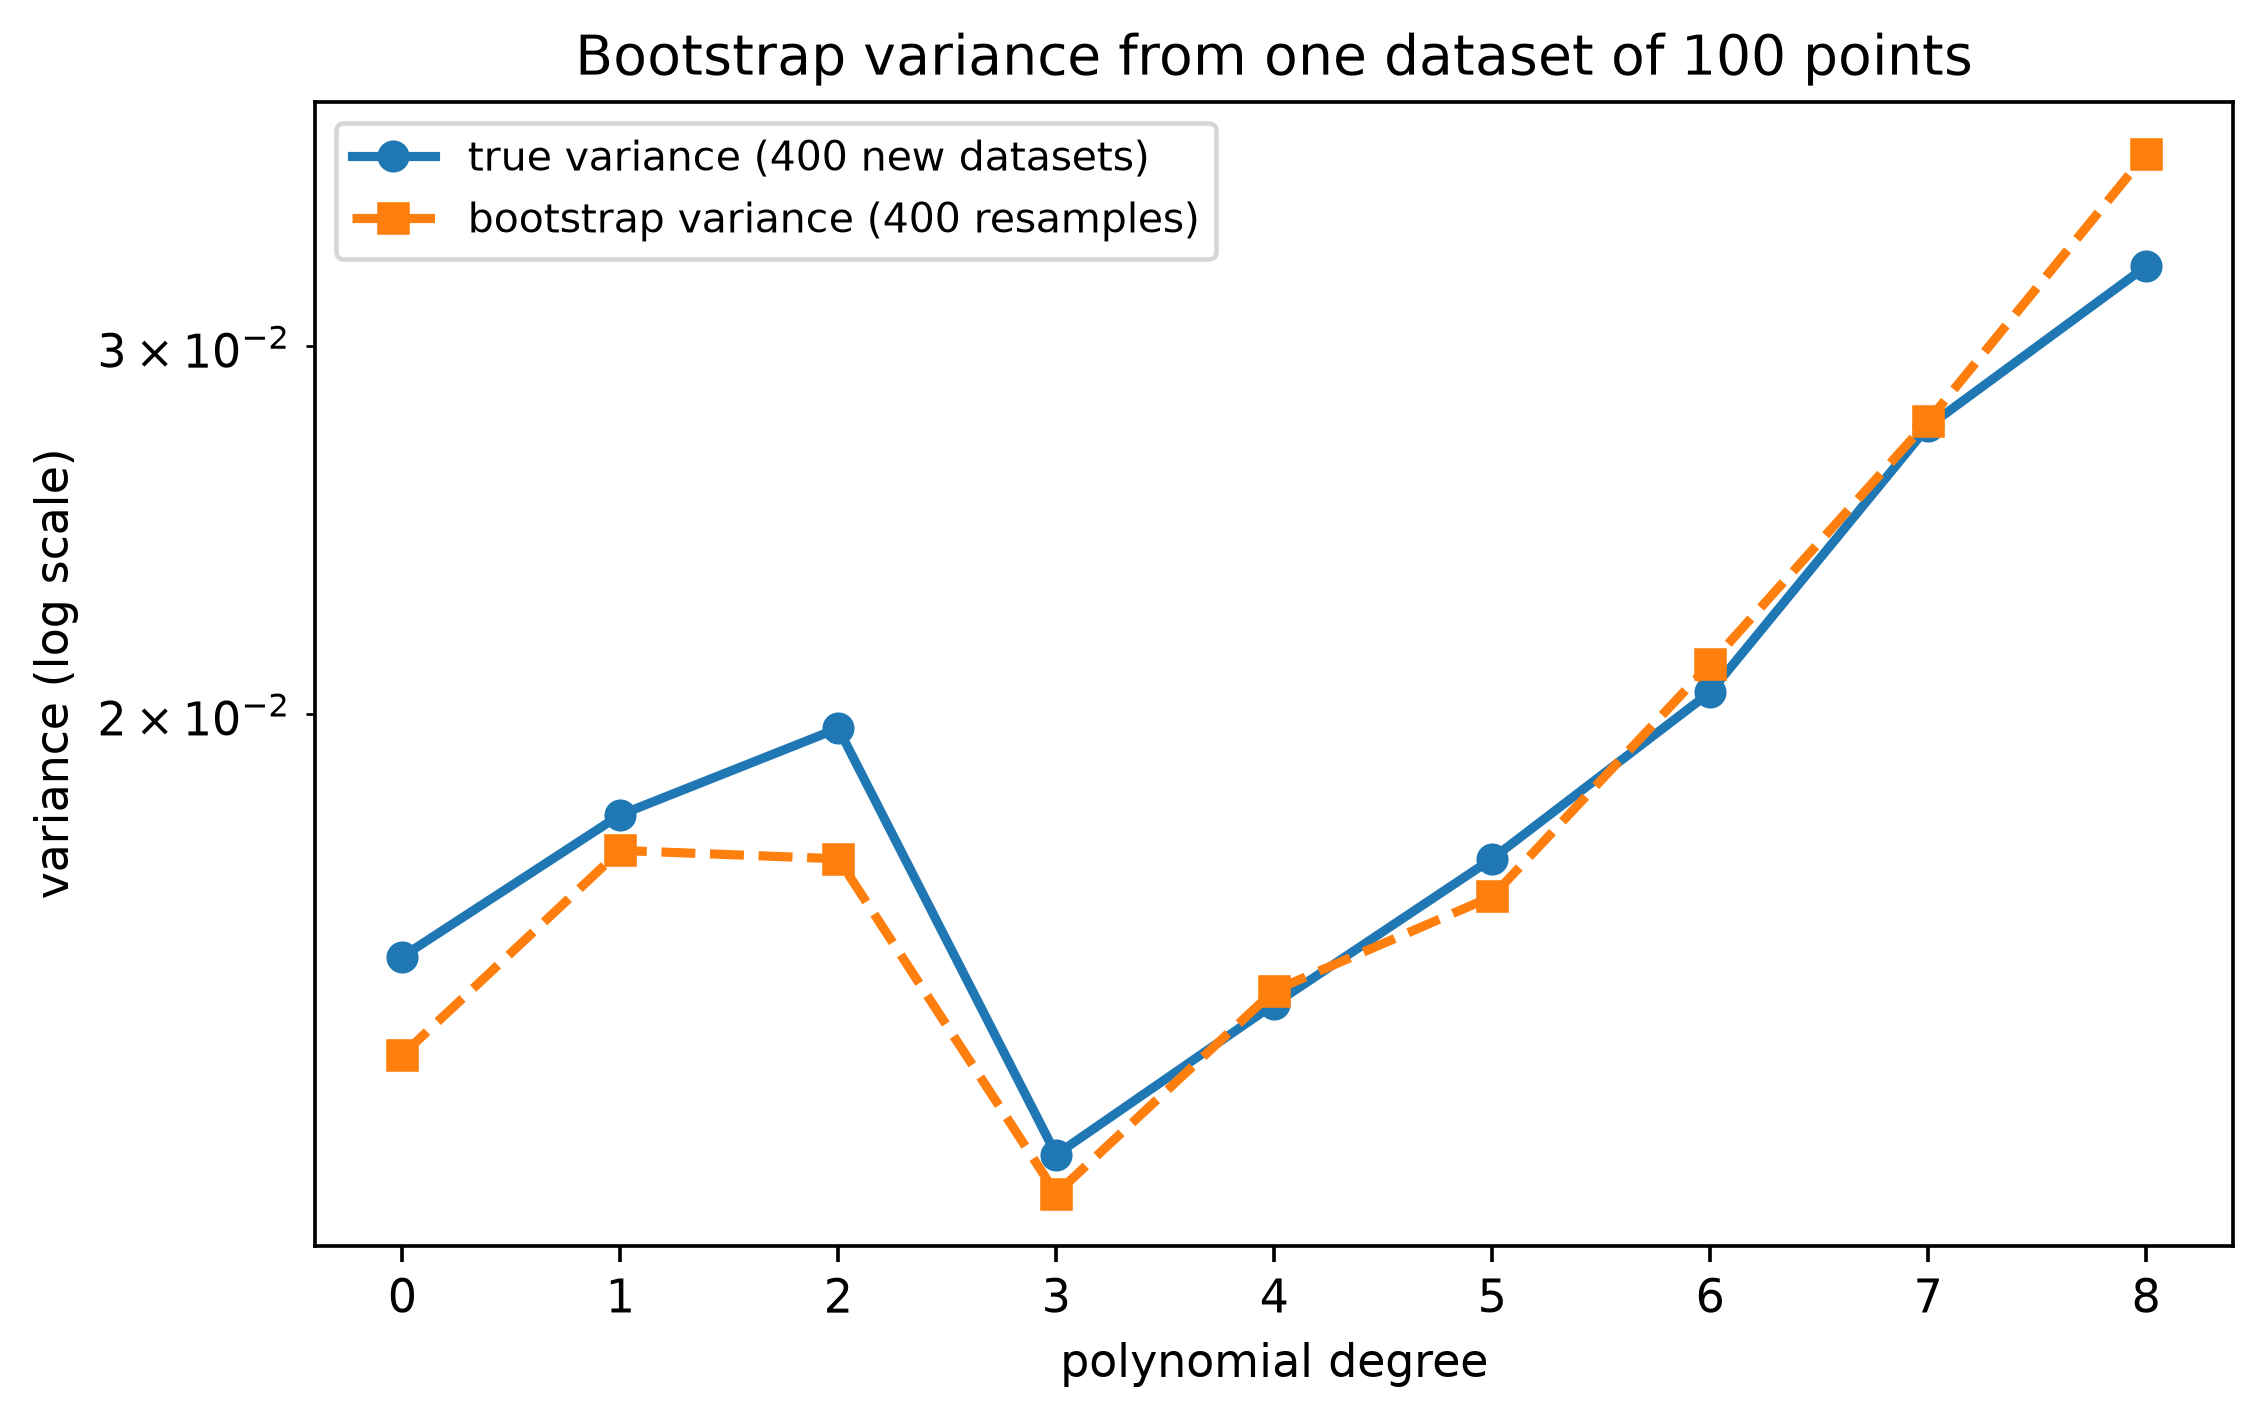

In [40]:
def true_variance(degrees, n_data=N_ONE, n_repeats=B):
    '''Variance of the fitted curves across BRAND-NEW datasets drawn from the world.'''
    out = []
    for degree in degrees:
        preds = np.empty((n_repeats, len(X_EVAL)))
        for r in range(n_repeats):
            x_r, y_r = sample_regression(n_data)                     # a genuinely new dataset every time
            preds[r] = predict_poly(X_EVAL, fit_poly(x_r, y_r, degree))
        out.append(np.mean(preds.var(axis=0)))
    return np.array(out)


real_var = true_variance(DEGREES_EX3)

comparison_var = pd.DataFrame({"true variance (new datasets)": real_var,
                               "bootstrap variance (one dataset)": boot_var},
                              index=pd.Index(DEGREES_EX3, name="degree"))
print(comparison_var.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(DEGREES_EX3, real_var, "o-", color="tab:blue", lw=2, label="true variance (400 new datasets)")
ax.plot(DEGREES_EX3, boot_var, "s--", color="tab:orange", lw=2, label="bootstrap variance (400 resamples)")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("variance (log scale)")
ax.set_title(f"Bootstrap variance from one dataset of {N_ONE} points")
ax.legend(fontsize=9)
plt.show()

**Line by line**

- `true_variance` : the same computation as `bootstrap_variance`, with one crucial difference. Instead of
  resampling the dataset we already have, it calls `sample_regression` to draw a genuinely new dataset every
  time. **This is only possible because we know the world.** In a real project this function could not be
  written, which is exactly the situation the bootstrap is designed for.
- Both functions return one number per degree, so the two arrays can be put side by side in a DataFrame and
  plotted on the same axes.
- `ax.set_yscale("log")` : the variance spans more than an order of magnitude across the degrees, so a log axis
  keeps the small values readable.

**Reading the plot.** The two curves are close, usually within 10 to 20 percent of each other. The bootstrap has
recovered both the **shape** of the variance curve and its **size**, from a method that never saw anything except
one dataset of 100 points. This is why the bootstrap is so widely used for error bars.

It even reproduces a quirk of the true curve: both curves **dip at degree 3**, so a cubic varies less than a
quadratic. The reason is that with random inputs a badly misspecified model has an extra source of variability.
A quadratic cannot follow the wave, so the compromise it settles on depends on exactly where this sample's
points happen to sit, and that shifts the fitted curve around. From degree 3 upwards the model can follow $f$,
that source disappears, and the only variability left is the noise, which then grows steadily with the number
of weights.

## Step 4: How much does the answer depend on which dataset you happened to get?

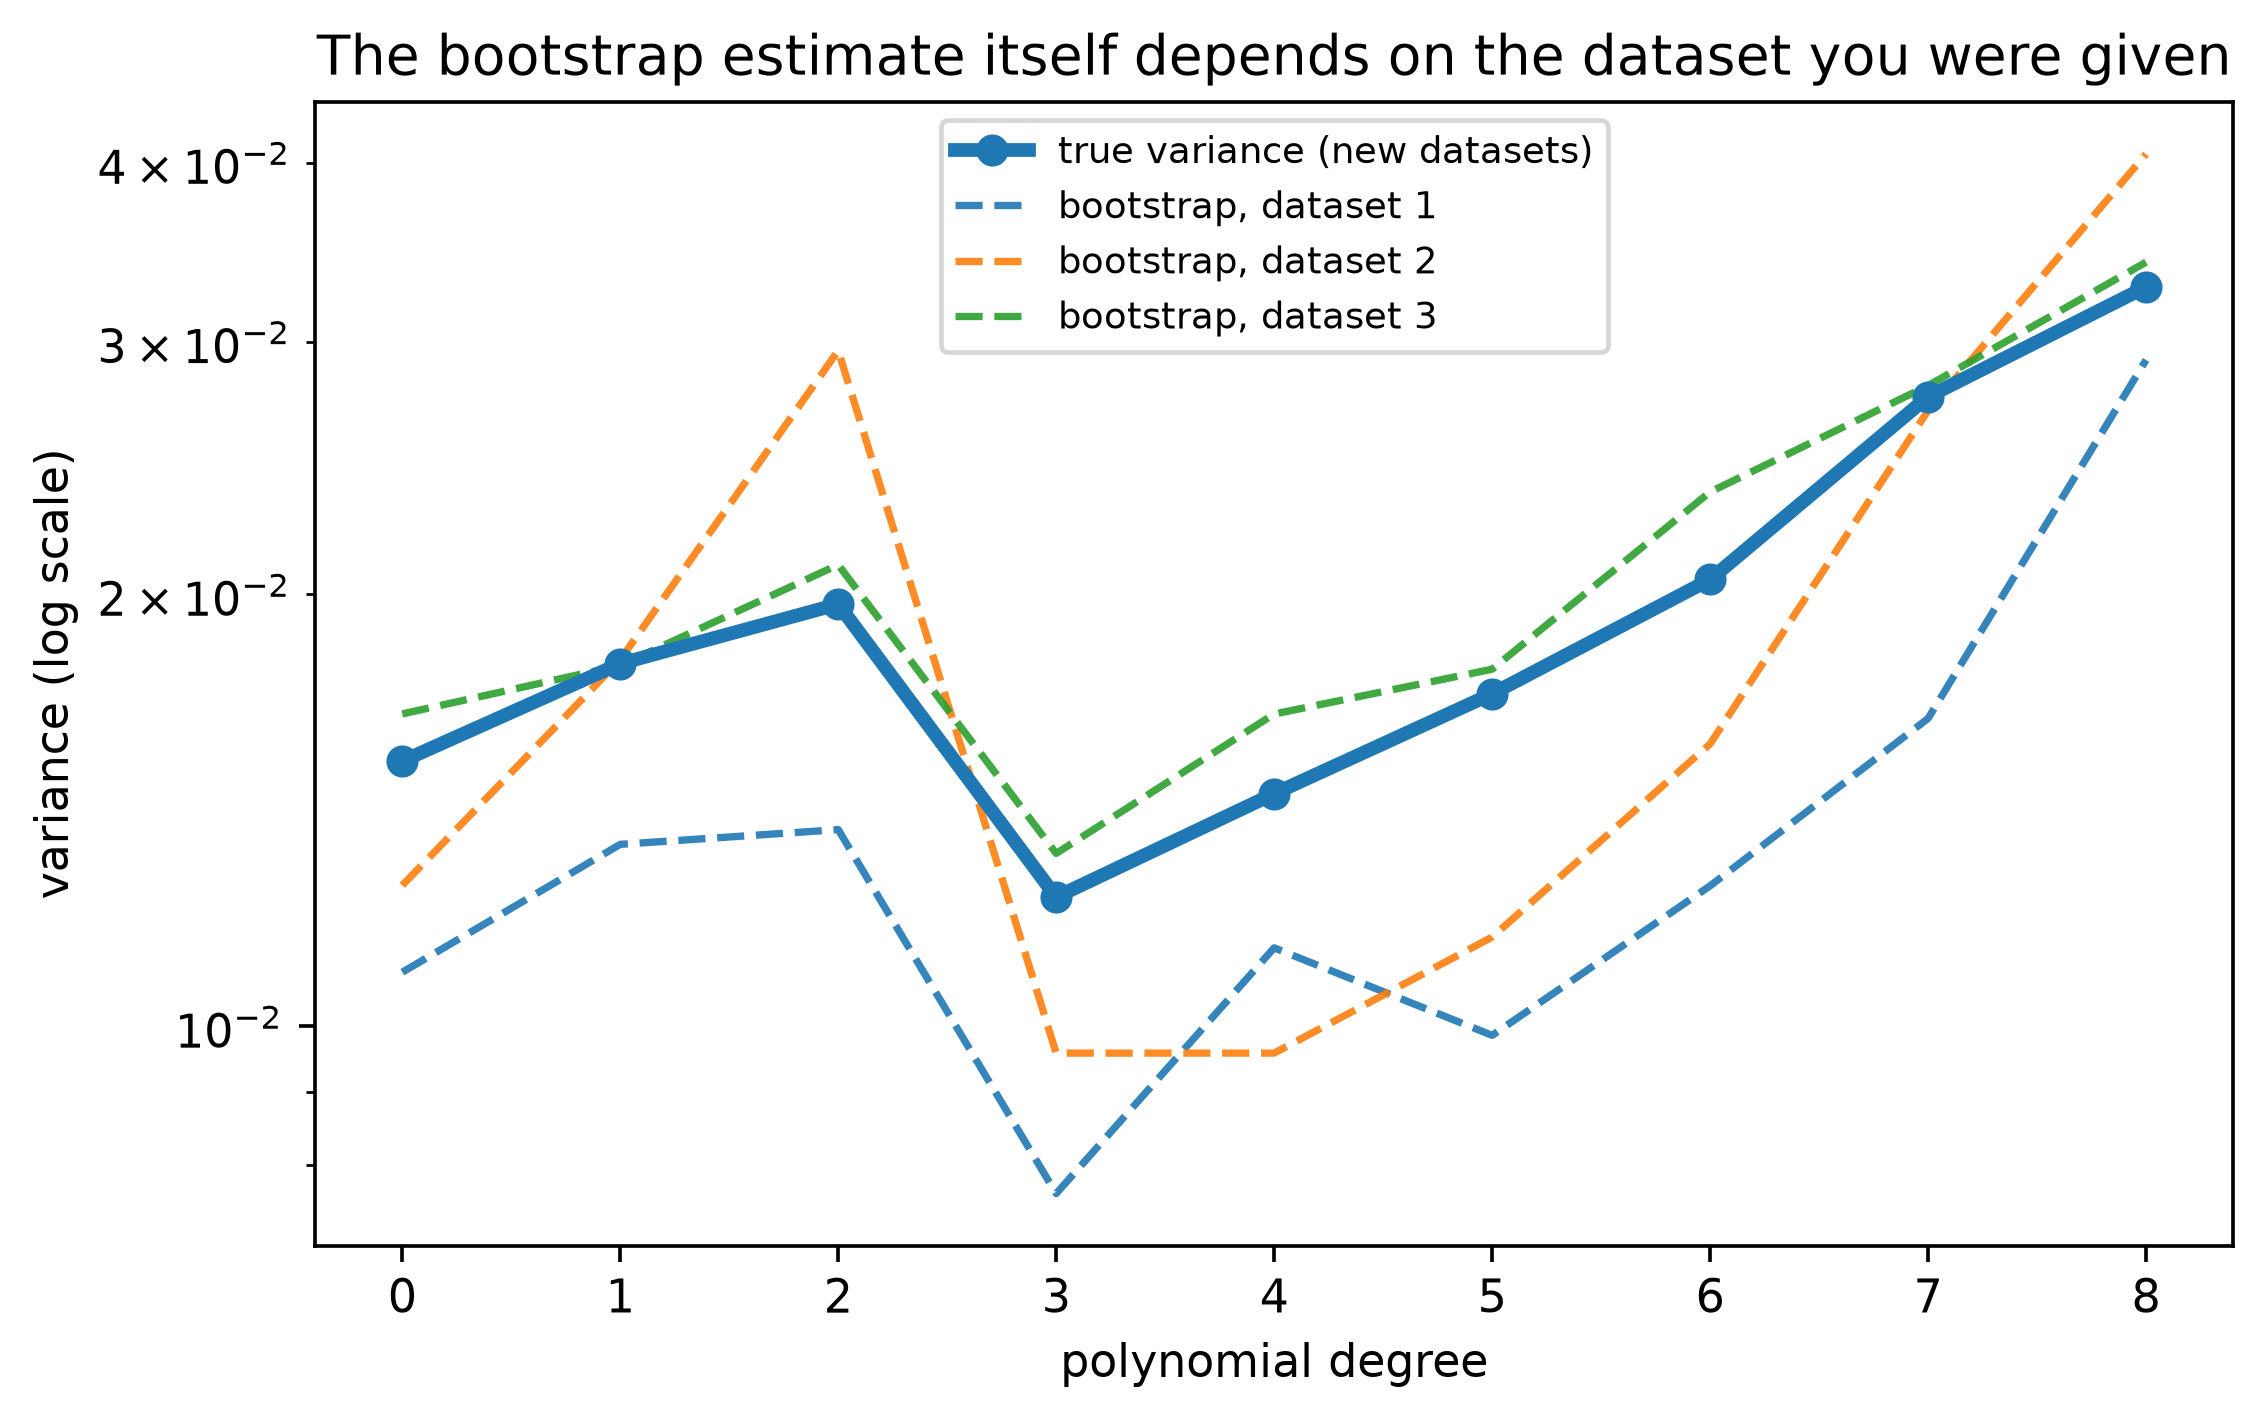

        true variance  bootstrap, dataset 1  bootstrap, dataset 2  bootstrap, dataset 3
degree                                                                                 
0              0.0153                0.0109                0.0125                0.0165
1              0.0179                0.0134                0.0180                0.0178
2              0.0197                0.0137                0.0296                0.0210
3              0.0123                0.0076                0.0096                0.0132
4              0.0145                0.0113                0.0096                0.0165
5              0.0171                0.0099                0.0115                0.0177
6              0.0205                0.0125                0.0157                0.0236
7              0.0275                0.0164                0.0269                0.0280
8              0.0328                0.0291                0.0405                0.0341


In [41]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(DEGREES_EX3, real_var, "o-", color="tab:blue", lw=3, label="true variance (new datasets)", zorder=3)

trial_rows = {}
for trial in range(3):                                          # three different "given" datasets
    x_t, y_t = sample_regression(N_ONE)                         # pretend this is the one we were handed
    bv_t = bootstrap_variance(x_t, y_t, DEGREES_EX3)
    trial_rows[f"bootstrap, dataset {trial + 1}"] = bv_t
    ax.plot(DEGREES_EX3, bv_t, "--", lw=1.6, alpha=0.9, label=f"bootstrap, dataset {trial + 1}")

ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("variance (log scale)")
ax.set_title("The bootstrap estimate itself depends on the dataset you were given")
ax.legend(fontsize=8)
plt.show()

trials_table = pd.DataFrame(trial_rows, index=pd.Index(DEGREES_EX3, name="degree"))
trials_table.insert(0, "true variance", real_var)
print(trials_table.round(4).to_string())

**Line by line**

- The loop repeats steps 1 and 2 three times, each time pretending that a different sample of 100 points is the
  only data available.
- `trial_rows` collects the three curves so they can be tabulated next to the truth.
- `zorder=3` keeps the thick blue reference curve drawn on top of the dashed ones.

**Reading the plot and the table.**

- All three bootstrap curves have the right shape. The trend is recovered reliably, and if your goal is to
  answer "does variance grow with degree, and roughly where does it take off?", the bootstrap answers it from
  one dataset.
- The individual values scatter around the truth in both directions, by roughly a third either way, and the
  scatter grows with the degree. That is expected. The bootstrap estimate is itself a statistic computed from
  one random dataset, so it has its own sampling variability, and the more unstable the model, the more unstable
  the estimate of its instability becomes.
- In this run two of the three datasets sit mostly a little **below** the truth. A resample can only reuse the
  points you were given, so it never produces a configuration more extreme than the one your sample contains,
  and the variability it reports is therefore slightly conservative at these sizes.
- The whole picture depends on having a reasonably large dataset. Repeat this with `N_ONE = 20` instead of 100
  and the bootstrap variance at the higher degrees blows up by orders of magnitude, because a resample of 20
  points contains only about 13 distinct inputs and often leaves a wide empty gap for a flexible polynomial to
  swing across. The bootstrap needs enough data that a resample still looks like the original.

## Step 5: Why the bootstrap cannot estimate the bias

**The short answer: bias needs the truth, and the truth is what you do not have.**

Look again at the definition:

$$\text{bias}^2(x) = \big(\bar{f}(x) - f(x)\big)^2$$

There are two quantities inside it.

* $\bar{f}(x)$, the average prediction over datasets. The bootstrap can approximate this: average the 400
  bootstrap fits. It is not perfect, but it is computable from data alone.
* $f(x)$, the true regression function $E[Y \mid X = x]$. This is **not** computable from data. It is exactly the
  thing the whole exercise of machine learning is trying to estimate. Any estimate of $f$ you plug into the
  formula is itself a model with its own bias, so the answer you get out is the bias of your model *relative to
  another model*, not relative to the truth.

Variance is different. Its definition, $E_D\big[(\hat{f}_D(x) - \bar{f}(x))^2\big]$, mentions only the model's own
predictions. Nothing about the truth appears, which is why resampling alone is enough.

Another way to see it: the bootstrap can tell you **how much your answer would wobble** if you had collected a
different sample, but it cannot tell you **whether the whole procedure is aimed at the wrong place**. Every
bootstrap resample comes from the same original dataset, so a systematic error shared by all of them stays
invisible.

**What you would do instead in practice.** You cannot separate bias from variance without the truth, but you do
not need to. What you need is the *total* error, and that is measurable on data the model has not seen. Hold out
a validation set, or use cross-validation, and pick the complexity with the smallest held-out error. The cell
below does that with a simple split, using only the single dataset, and finds a degree close to the best degree
of Part 5.

In [42]:
n_val = N_ONE // 3                                   # keep a third of the dataset for validation
perm = rng.permutation(N_ONE)                        # a random ordering of the row positions
val_idx, fit_idx = perm[:n_val], perm[n_val:]        # split into validation rows and fitting rows

val_errors = []
for degree in DEGREES_EX3:
    w = fit_poly(x_one[fit_idx], y_one[fit_idx], degree)              # fit on the fitting part only
    val_errors.append(np.mean((predict_poly(x_one[val_idx], w) - y_one[val_idx]) ** 2))   # error on held-out data

val_errors = np.array(val_errors)
best_by_validation = DEGREES_EX3[int(val_errors.argmin())]

print("validation error per degree:", val_errors.round(3))
print(f"\ndegree chosen by validation on the single dataset : {best_by_validation}")
print(f"degree chosen in Part 5 using the true world      : {bv['measured test error'].idxmin()}")
print(f"sigma^2, the floor that the validation error sits above: {NOISE_VAR}")

validation error per degree: [1.402 0.732 0.47  0.415 0.334 0.306 0.307 0.343 0.319]

degree chosen by validation on the single dataset : 5
degree chosen in Part 5 using the true world      : 4
sigma^2, the floor that the validation error sits above: 0.25


**Line by line**

- `rng.permutation(N_ONE)` : a random shuffle of the positions `0 .. 99`. Slicing the shuffled array is the
  simplest correct way to split data, the same method used in Practical 2.
- `perm[:n_val]` and `perm[n_val:]` : roughly a third of the points for validation, the rest for fitting. The
  model never sees the validation rows while it is being fitted.
- `np.mean((predict_poly(x_one[val_idx], w) - y_one[val_idx]) ** 2)` : the mean squared error on the held-out
  rows. Because those rows were not used for fitting, this is an honest estimate of the model's error on new
  data, noise floor included.
- `DEGREES_EX3[int(val_errors.argmin())]` : the degree with the smallest validation error.

**Reading the output.** The chosen degree is in the same small range as the best degree found in Part 5 with
full knowledge of the world. The validation error also sits above $\sigma^2 = 0.25$, as it must.

Two honest caveats to keep in mind. With only about 33 validation points this estimate is noisy, and re-running
the split can change the winner by a degree or so; k-fold cross-validation, which rotates the held-out part and
averages, is the standard fix. And once you have used the validation set to choose the degree, that set is no
longer an unbiased estimate of the final model's error, for the same reason the brute-force threshold in Part 2d
looked slightly too good. Reporting a final number needs a third, untouched set.

**What to take away from Exercise 3**

1. Resampling your own data mimics drawing new data well enough to estimate **variance** from a single dataset.
2. It cannot estimate **bias**, because bias is defined against a truth you do not have. No amount of resampling
   creates information that the original sample never contained.
3. In practice you do not need the split into bias and variance to choose a model. You need held-out error, and
   the bias-variance decomposition is the explanation of *why* that held-out error is U-shaped.

---
# Exercise 4: Moving the sweet spot

**The question.** The bottom of the U-curve in Part 5 is not a fixed property of the problem. Four things are
varied here: the amount of data, the noise level, the regularisation strength, and whether the inputs are fixed
or random.

## Step 1: More data

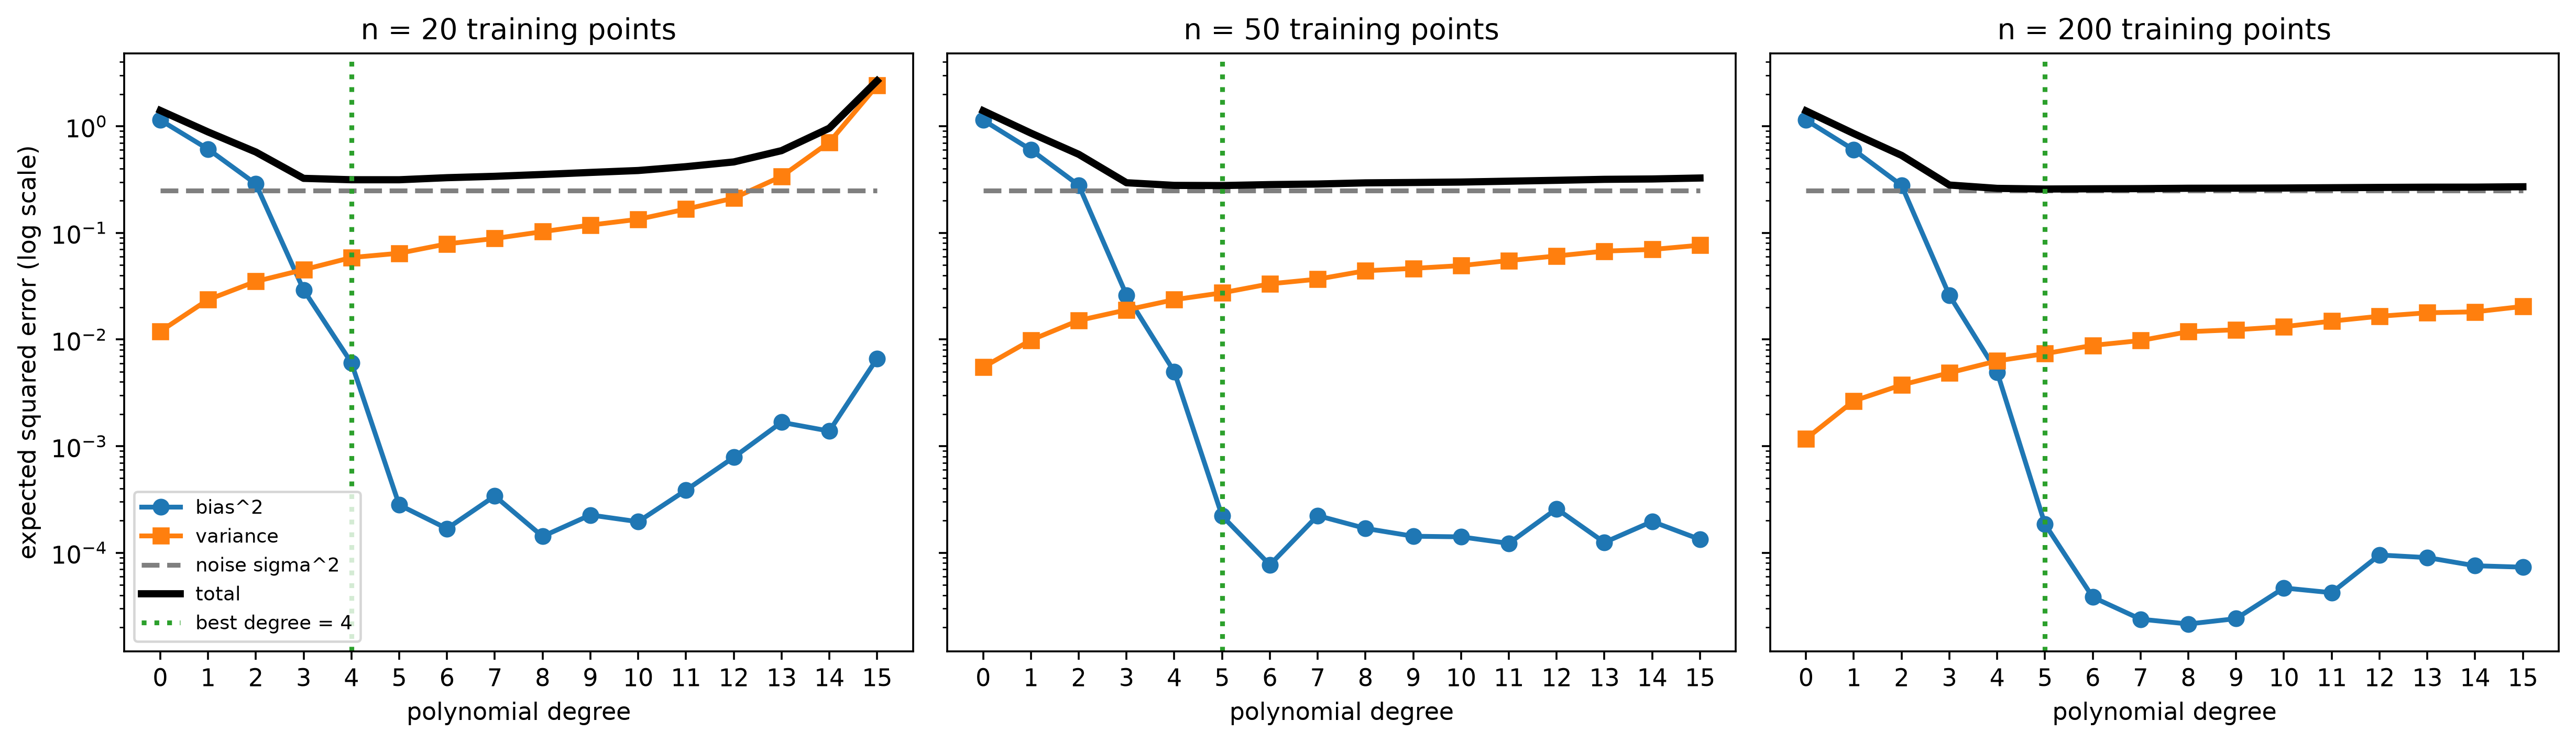

         best degree  lowest test error  variance at degree 5  variance at degree 15  bias^2 at degree 2
n_train                                                                                                 
20                 4             0.3148                0.0644                 2.4073              0.2878
50                 5             0.2768                0.0274                 0.0765              0.2800
200                5             0.2568                0.0074                 0.0204              0.2786


In [43]:
sizes = [20, 50, 200]                                   # training-set sizes to compare
tables_by_size = {}                                     # keep one bias-variance table per size

for n in sizes:
    x_fixed_n = np.linspace(-1.0, 1.0, n)               # n evenly spaced inputs instead of 20
    tables_by_size[n] = bias_variance_table(DEGREES, x_train=x_fixed_n, n_repeats=300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)
for ax, n in zip(axes, sizes):
    table = tables_by_size[n]
    ax.plot(DEGREES, table["bias^2"], "o-", color="tab:blue", lw=2, label="bias^2")
    ax.plot(DEGREES, table["variance"], "s-", color="tab:orange", lw=2, label="variance")
    ax.plot(DEGREES, table["noise"], "--", color="tab:grey", lw=2, label="noise sigma^2")
    ax.plot(DEGREES, table["bias^2 + variance + noise"], "-", color="black", lw=3, label="total")
    best_n = table["measured test error"].idxmin()
    ax.axvline(best_n, color="tab:green", ls=":", lw=2, label=f"best degree = {best_n}")
    ax.set_yscale("log")
    ax.set_xlabel("polynomial degree")
    ax.set_title(f"n = {n} training points")
    ax.set_xticks(DEGREES)
axes[0].set_ylabel("expected squared error (log scale)")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

summary_sizes = pd.DataFrame({
    "best degree": {n: tables_by_size[n]["measured test error"].idxmin() for n in sizes},
    "lowest test error": {n: tables_by_size[n]["measured test error"].min() for n in sizes},
    "variance at degree 5": {n: tables_by_size[n].loc[5, "variance"] for n in sizes},
    "variance at degree 15": {n: tables_by_size[n].loc[15, "variance"] for n in sizes},
    "bias^2 at degree 2": {n: tables_by_size[n].loc[2, "bias^2"] for n in sizes},
})
summary_sizes.index.name = "n_train"
print(summary_sizes.round(4).to_string())

**Line by line**

- `x_fixed_n = np.linspace(-1.0, 1.0, n)` : the same interval covered by more points. Passing it as `x_train`
  is all that is needed, because `bias_variance_table` and `draw_training_set` both read the number of points
  from the array they are given.
- `n_repeats=300` : fewer repeats than the 500 of Part 5, to keep three full experiments quick. The curves get
  a little noisier and the conclusions do not change.
- `tables_by_size[n] = ...` : a dictionary keyed by the sample size, so each table can be pulled out again for
  the plot and the summary.
- The dictionary comprehensions inside `pd.DataFrame({...})` build one column each, keyed by `n`, which becomes
  the row index of the summary table.
- `ax.set_yscale("log")` : with variance at degree 15 falling from roughly 2.4 down to 0.02 across the three
  panels, only a log axis lets the same axis range serve all three.

**Reading the results.**

- **Variance shrinks roughly in proportion to $1/n$.** Ten times more data gives roughly a tenth of the
  variance at any fixed degree, and much more than a tenth at the highest degrees, where 20 points were barely
  enough to pin down 16 weights in the first place.
- **Bias² barely moves.** Compare the "bias² at degree 2" column: 0.288, 0.280, 0.279 as $n$ goes from 20 to
  200, a drift of about 3 percent against a variance that changed by a factor of 100. Bias is a property of the
  **model family** and the truth, not of the sample size. A quadratic cannot follow a full wave, and it will not
  learn to however many points you give it. (The small drift is real rather than noise: the fixed grid of inputs
  changes slightly when $n$ changes, and the best quadratic approximation depends a little on which inputs are
  being fitted.)
- **The best degree moves right, but only a little**, typically from 4 to about 5 or 6. The U also becomes much
  flatter on its right-hand side, so the penalty for choosing a slightly too complex model is far smaller when
  data is plentiful.

**Why the best degree cannot move much further.** Look at the bias² column in any of these tables. From degree 5
onwards it is already essentially zero, because a degree-5 polynomial can reproduce this particular $f$ over
$[-1, 1]$ to within a few thousandths. Once bias has been eliminated, extra degrees can only add variance and
have nothing left to buy. The optimum therefore stalls at the smallest degree that removes the bias, no matter
how much data arrives. If the truth were a more complicated function, whose bias kept falling up to degree 12,
more data would push the optimum much further right.

## Step 2: More noise

       sigma^2 (noise)  best degree  bias^2 at degree 2  variance at degree 8  variance / sigma^2 at degree 8
sigma                                                                                                        
0.2               0.04            5              0.2864                0.0165                          0.4119
0.5               0.25            4              0.2883                0.0995                          0.3980
1.0               1.00            3              0.2883                0.3833                          0.3833


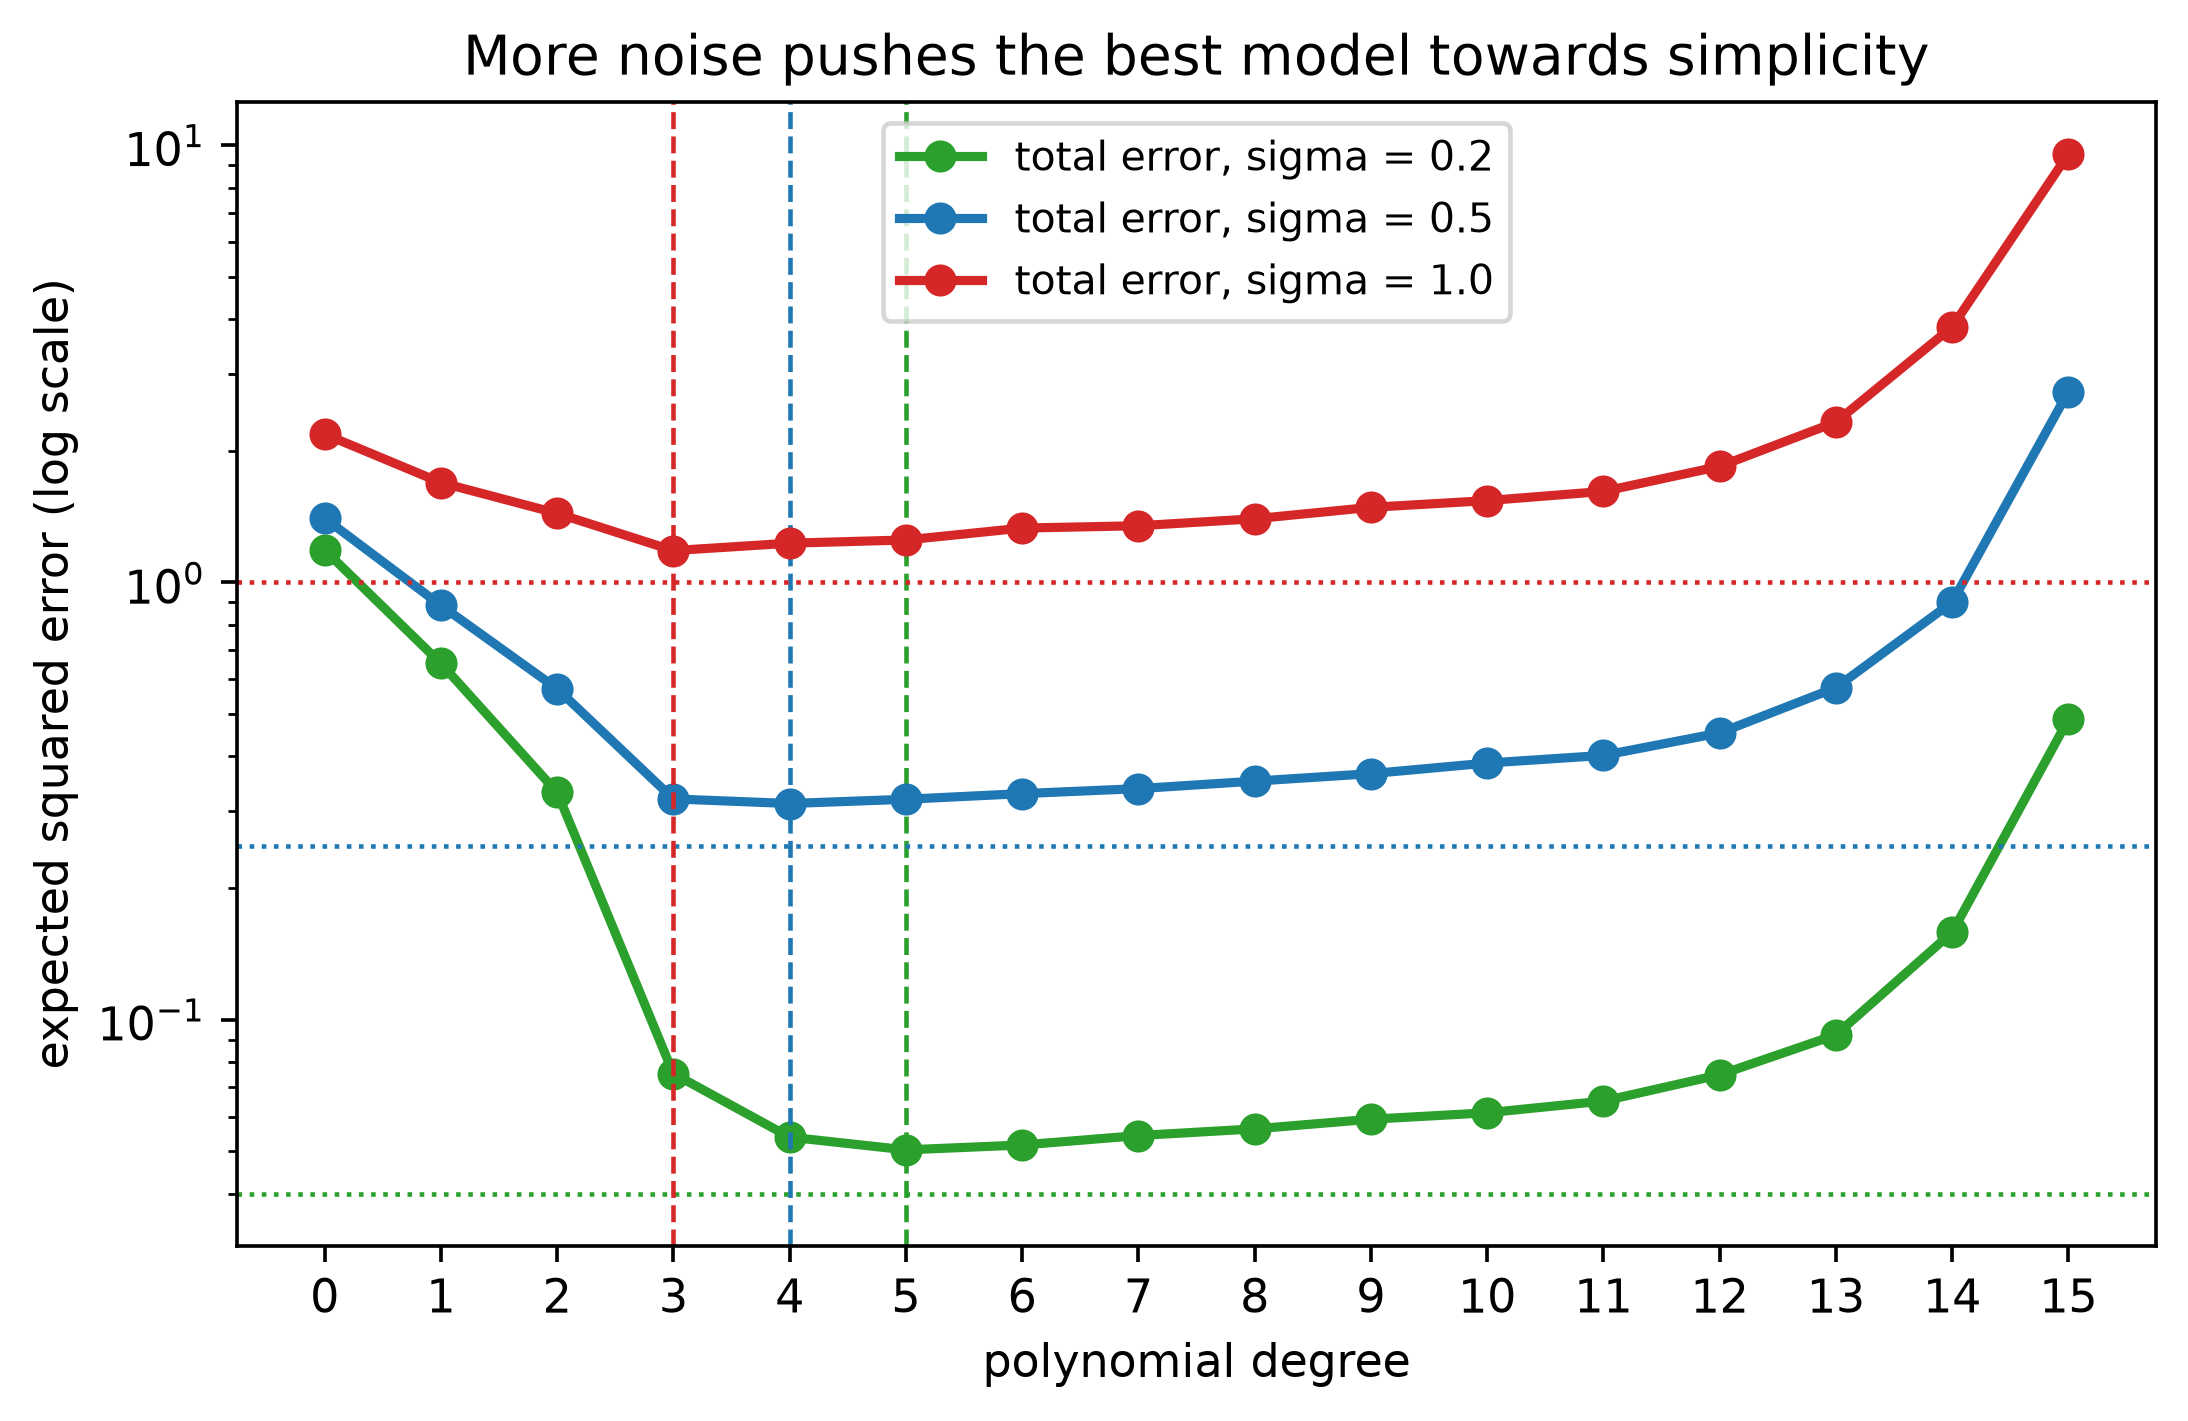

In [44]:
noise_levels = [0.2, 0.5, 1.0]                          # sigma values to compare (0.5 is the original)
tables_by_noise = {}

for sd in noise_levels:
    tables_by_noise[sd] = bias_variance_table(DEGREES, noise_sd=sd, n_repeats=300)

summary_noise = pd.DataFrame({
    "sigma^2 (noise)": {sd: sd ** 2 for sd in noise_levels},
    "best degree": {sd: tables_by_noise[sd]["measured test error"].idxmin() for sd in noise_levels},
    "bias^2 at degree 2": {sd: tables_by_noise[sd].loc[2, "bias^2"] for sd in noise_levels},
    "variance at degree 8": {sd: tables_by_noise[sd].loc[8, "variance"] for sd in noise_levels},
    "variance / sigma^2 at degree 8": {sd: tables_by_noise[sd].loc[8, "variance"] / sd ** 2
                                       for sd in noise_levels},
})
summary_noise.index.name = "sigma"
print(summary_noise.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for sd, color in zip(noise_levels, ["tab:green", "tab:blue", "tab:red"]):
    table = tables_by_noise[sd]
    ax.plot(DEGREES, table["measured test error"], "o-", color=color, lw=2, label=f"total error, sigma = {sd}")
    ax.axhline(sd ** 2, color=color, ls=":", lw=1)                     # that world's floor
    ax.axvline(table["measured test error"].idxmin(), color=color, ls="--", lw=1)
ax.set_yscale("log")
ax.set_xticks(DEGREES)
ax.set_xlabel("polynomial degree")
ax.set_ylabel("expected squared error (log scale)")
ax.set_title("More noise pushes the best model towards simplicity")
ax.legend(fontsize=9)
plt.show()

**Line by line**

- `bias_variance_table(DEGREES, noise_sd=sd, ...)` : only the noise level changes. The function uses `noise_sd`
  both to generate the training sets and to fill the "noise" column with $\sigma^2$.
- `"variance / sigma^2 at degree 8"` : the variance divided by the noise variance. This ratio is the
  interesting quantity, as the reading below explains.
- `ax.axhline(sd ** 2, ...)` : each noise level has its own floor, drawn in the matching colour.
- `ax.axvline(..., ls="--")` : the best degree for each noise level, again colour matched, so the leftward drift
  is visible directly on the plot.

**Reading the results.**

- **Bias² is untouched.** Same numbers for every $\sigma$, to three decimals. Noise does not change how well the
  average polynomial of a given degree can approximate $f$.
- **Variance scales with $\sigma^2$.** The last column is nearly constant across the three rows: variance divided
  by $\sigma^2$ is about the same number. Doubling the noise from 0.5 to 1.0 multiplies the variance by about 4.
  This makes sense, since the model is fitting the noise, so the amount it can be dragged around is proportional
  to how large the noise is.
- **The floor rises**, from 0.04 to 0.25 to 1.0.
- **The best degree moves left as noise grows.** With $\sigma = 0.2$ a more flexible model is affordable, because
  its extra variance is small. With $\sigma = 1.0$ flexibility is expensive and a simpler model wins.

**The rule of thumb this supports.** Noisy data calls for simpler models; clean data can support complex ones.
Put together with step 1: complexity should grow with the amount of data and shrink with the amount of noise.

## Step 3: Ridge regularisation as a different complexity knob

Instead of controlling flexibility by choosing the degree, fix the degree at 15 and control it with the ridge
penalty from Practical 1:

$$w = \big(\Phi^\top \Phi + \lambda I\big)^{-1}\Phi^\top y$$

Large $\lambda$ forces the weights towards zero, so the fitted curve becomes flat and rigid. Small $\lambda$
leaves the degree-15 polynomial free to do whatever it likes. So $\lambda$ is a complexity knob that runs
**backwards**: small $\lambda$ means complex, large $\lambda$ means simple.

In [45]:
def fit_poly_ridge(x, y, degree, lam):
    '''Ridge-penalised polynomial fit: solve (Phi^T Phi + lam I) w = Phi^T y.'''
    Phi = poly_features(x, degree)                                     # (n, degree + 1) design matrix
    A = Phi.T @ Phi + lam * np.eye(Phi.shape[1])                       # penalised square matrix
    b = Phi.T @ y                                                      # right-hand side
    return np.linalg.solve(A, b)                                       # the fitted weights


def bias_variance_ridge(lams, degree=15, x_train=X_TRAIN_FIXED, noise_sd=NOISE_SD, n_repeats=300):
    '''The bias-variance decomposition as a function of the ridge strength, at a FIXED degree.'''
    rows = []
    for lam in lams:
        preds = np.empty((n_repeats, len(X_EVAL)))
        for r in range(n_repeats):
            y_tr = draw_training_set(x_train, noise_sd)                # a fresh training set
            w = fit_poly_ridge(x_train, y_tr, degree, lam)             # the only changed line
            preds[r] = predict_poly(X_EVAL, w)
        avg_pred = preds.mean(axis=0)
        rows.append({"lambda": lam,
                     "bias^2": np.mean((avg_pred - F_EVAL) ** 2),
                     "variance": np.mean(preds.var(axis=0)),
                     "noise": noise_sd ** 2})
    table = pd.DataFrame(rows).set_index("lambda")
    table["total"] = table["bias^2"] + table["variance"] + table["noise"]
    return table


LAMS = np.logspace(-8, 2, 11)                      # 1e-8, 1e-7, ..., 1e2: eleven strengths
ridge_table = bias_variance_ridge(LAMS)
print(ridge_table.round(4).to_string())

best_lam = ridge_table["total"].idxmin()
print(f"\nbest lambda : {best_lam:.0e}   total error {ridge_table.loc[best_lam, 'total']:.4f}")
print(f"for comparison, the best DEGREE knob in Part 5 reached {bv['measured test error'].min():.4f}")

            bias^2  variance  noise   total
lambda                                     
1.0000e-08  0.0014    0.3518   0.25  0.6032
1.0000e-07  0.0003    0.2297   0.25  0.4800
1.0000e-06  0.0010    0.1764   0.25  0.4274
1.0000e-05  0.0003    0.1412   0.25  0.3915
1.0000e-04  0.0005    0.1144   0.25  0.3649
1.0000e-03  0.0003    0.0971   0.25  0.3475
1.0000e-02  0.0046    0.0684   0.25  0.3230
1.0000e-01  0.0347    0.0517   0.25  0.3363
1.0000e+00  0.2038    0.0328   0.25  0.4867
1.0000e+01  0.6585    0.0125   0.25  0.9210
1.0000e+02  1.0340    0.0008   0.25  1.2848

best lambda : 1e-02   total error 0.3230
for comparison, the best DEGREE knob in Part 5 reached 0.3120


**Line by line**

- `fit_poly_ridge` : the normal equations of Practical 1 with `lam * np.eye(...)` added to the square matrix.
  `np.eye(k)` is the identity matrix, so this adds `lam` to each diagonal entry, which is exactly what the
  penalty $\lambda \lVert w \rVert^2$ contributes.
- `np.linalg.solve(A, b)` : solves the linear system rather than forming an inverse, the habit from Practical 1.
  With a ridge term added, `A` is always invertible, which is one of the reasons ridge is useful for a degree-15
  Vandermonde matrix whose columns are nearly parallel.
- `bias_variance_ridge` : a copy of `bias_variance_table` with the loop running over `lam` instead of `degree`,
  and with `fit_poly_ridge` in place of `fit_poly`. The measured test error column is dropped to keep it short;
  the decomposition has already been verified in Part 5.
- `np.logspace(-8, 2, 11)` : eleven values spaced evenly in the **exponent**, that is $10^{-8}$ to $10^{2}$. Use
  `logspace` whenever a parameter spans orders of magnitude, as regularisation strengths always do.
- `.idxmin()` on the total column returns the value of `lambda` itself, because `lambda` is the index of the
  table.

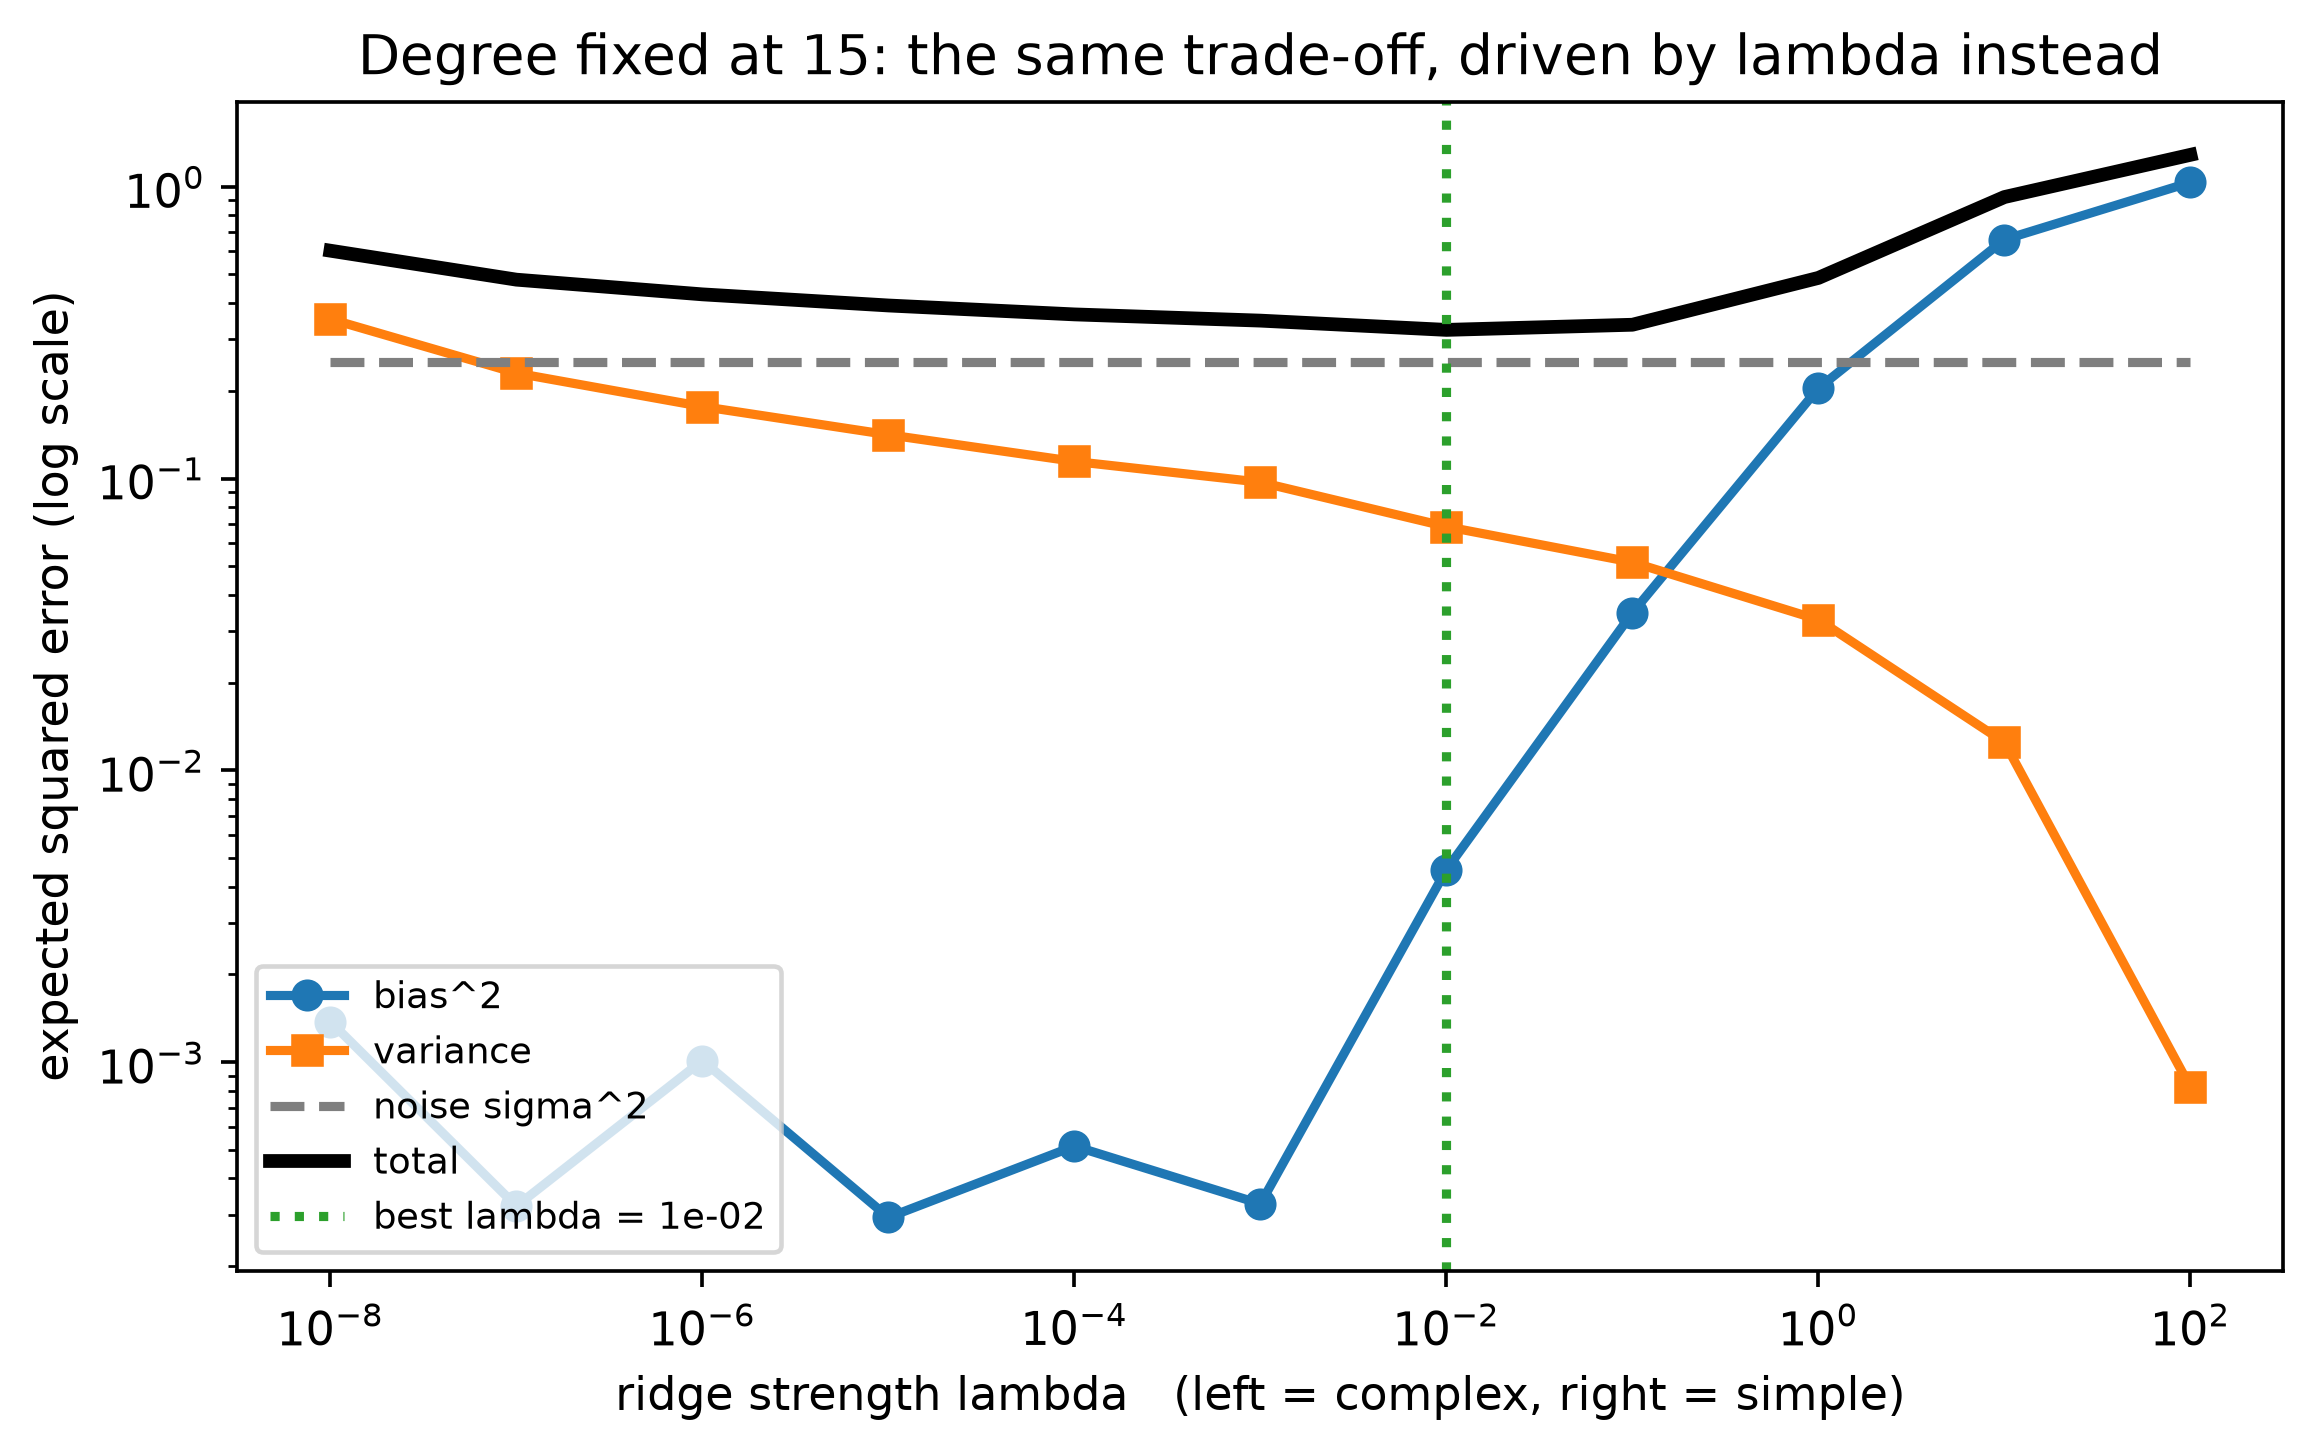

In [46]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(LAMS, ridge_table["bias^2"], "o-", color="tab:blue", lw=2, label="bias^2")
ax.plot(LAMS, ridge_table["variance"], "s-", color="tab:orange", lw=2, label="variance")
ax.plot(LAMS, ridge_table["noise"], "--", color="tab:grey", lw=2, label="noise sigma^2")
ax.plot(LAMS, ridge_table["total"], "-", color="black", lw=3, label="total")
ax.axvline(best_lam, color="tab:green", ls=":", lw=2, label=f"best lambda = {best_lam:.0e}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ridge strength lambda   (left = complex, right = simple)")
ax.set_ylabel("expected squared error (log scale)")
ax.set_title("Degree fixed at 15: the same trade-off, driven by lambda instead")
ax.legend(fontsize=8, loc="lower left")
plt.show()

**Line by line**

- `ax.set_xscale("log")` : the x-axis is the ridge strength, which spans ten orders of magnitude, so it must be
  logarithmic. Both axes are now logarithmic, which is the standard way to present a regularisation path.
- Everything else is the same plotting code as the degree version, which is the point: the two knobs produce the
  same kind of picture.

**Reading the plot.**

- On the **left** ($\lambda \approx 10^{-8}$, almost no penalty) the model is effectively the unpenalised
  degree-15 polynomial: bias² near zero, variance large. This is the right-hand end of the Part 5 U-curve.
- On the **right** ($\lambda = 100$) the weights are crushed towards zero, the fitted curve is nearly flat,
  variance is tiny and bias² is enormous. This is the left-hand end of the Part 5 U-curve.
- In between the total error passes through a minimum. **The U-curve appears again, running right to left**,
  because the $\lambda$ axis is the complexity axis reversed.

**The wider point.** Model complexity is not the same thing as the number of parameters. Here the number of
parameters is 16 in every single run, and yet the model goes from wildly flexible to almost constant. What
actually matters is how much freedom the fitting procedure is allowed to use, which is why $\lambda$, the number
of neighbours $k$, the number of bins, the depth of a tree and the number of training epochs are all complexity
knobs of the same kind.

Comparing the two knobs on this problem, the best ridge setting reaches a total error close to the best degree
setting. Neither is magic; both are ways of landing near the bottom of the same U.

## Step 4: Random inputs instead of a fixed grid

        bias^2 (random x)  variance (random x)  variance (fixed x, Part 5)  ratio random / fixed
degree                                                                                          
0              1.1410e+00           7.7000e-02                       0.011            6.8120e+00
1              6.0100e-01           9.8000e-02                       0.024            4.0570e+00
2              2.8600e-01           1.6700e-01                       0.032            5.2970e+00
3              3.0000e-02           1.6700e-01                       0.045            3.7100e+00
4              1.7000e-02           2.7900e-01                       0.054            5.1400e+00
5              2.0000e-03           5.2000e-01                       0.066            7.8420e+00
6              1.0000e-02           3.7590e+00                       0.079            4.7856e+01
7              6.5000e-02           3.8061e+02                       0.091            4.1943e+03
8              8.9000e-01     

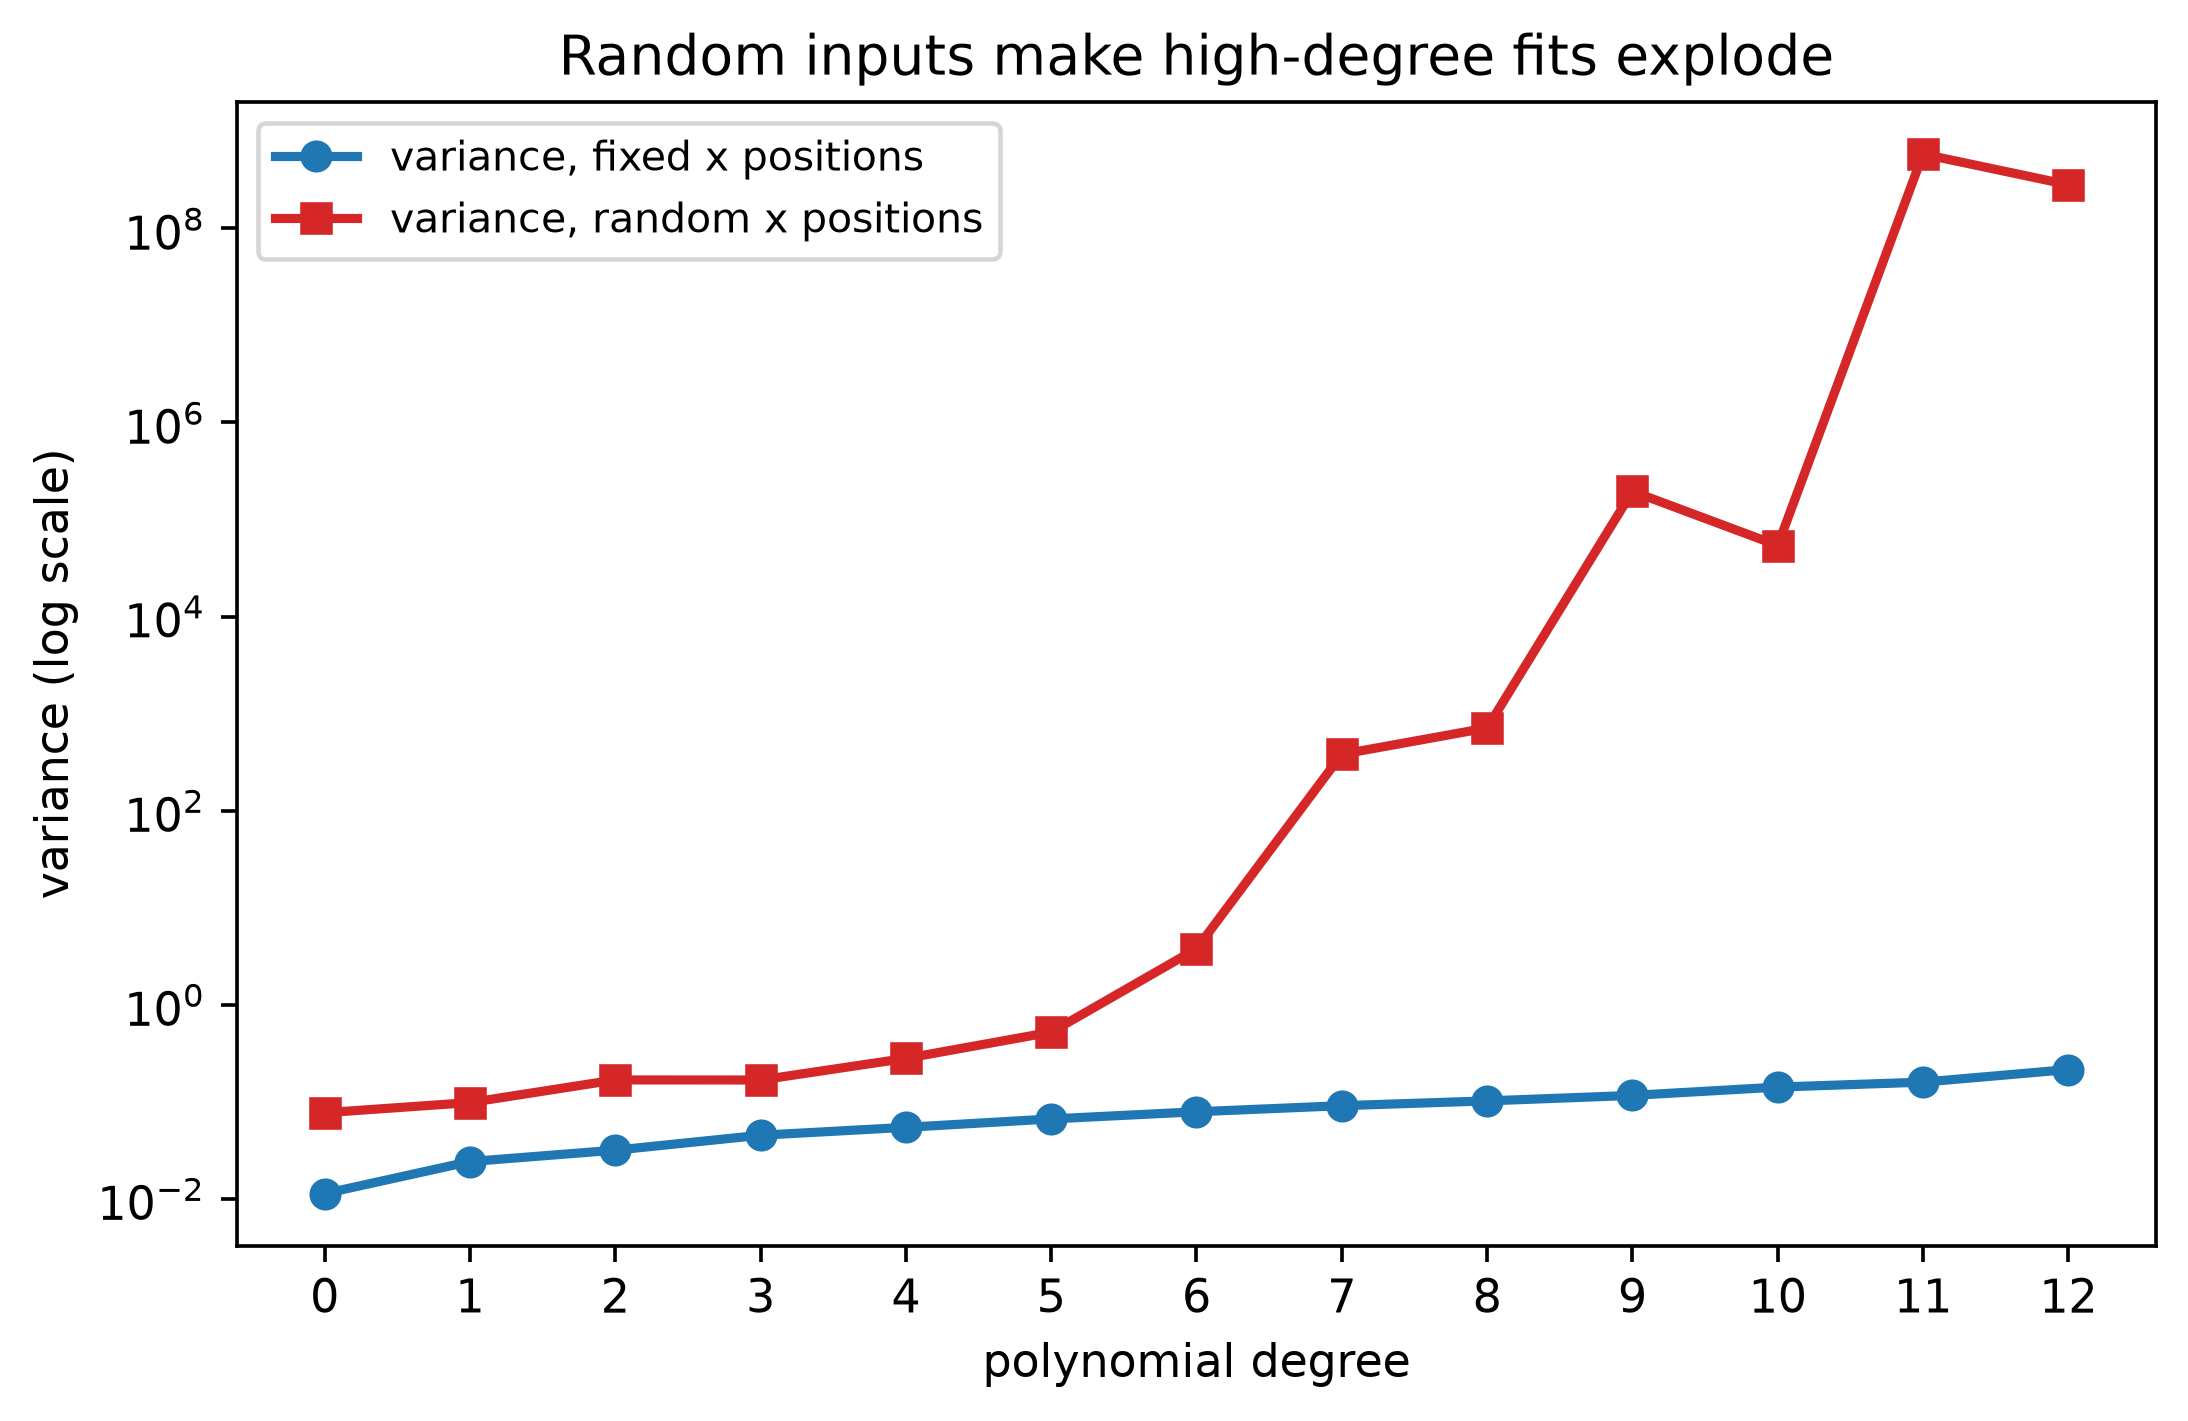

In [47]:
def bias_variance_random_x(degrees, n_data=N_TRAIN, noise_sd=NOISE_SD, n_repeats=300):
    '''Like bias_variance_table, but each training set gets NEW random x positions.'''
    rows = []
    for degree in degrees:
        preds = np.empty((n_repeats, len(X_EVAL)))
        for r in range(n_repeats):
            x_r = np.sort(rng.uniform(-1.0, 1.0, n_data))              # random inputs, redrawn every time
            y_r = f_true(x_r) + rng.normal(0.0, noise_sd, size=n_data) # noisy outputs at those inputs
            preds[r] = predict_poly(X_EVAL, fit_poly(x_r, y_r, degree))
        rows.append({"degree": degree,
                     "bias^2 (random x)": np.mean((preds.mean(axis=0) - F_EVAL) ** 2),
                     "variance (random x)": np.mean(preds.var(axis=0))})
    return pd.DataFrame(rows).set_index("degree")


DEGREES_EX4 = list(range(0, 13))                                        # degrees 0 to 12
random_x_table = bias_variance_random_x(DEGREES_EX4)
random_x_table["variance (fixed x, Part 5)"] = bv.loc[DEGREES_EX4, "variance"]
random_x_table["ratio random / fixed"] = (random_x_table["variance (random x)"]
                                          / random_x_table["variance (fixed x, Part 5)"])
print(random_x_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(DEGREES_EX4, random_x_table["variance (fixed x, Part 5)"], "o-", color="tab:blue", lw=2,
        label="variance, fixed x positions")
ax.plot(DEGREES_EX4, random_x_table["variance (random x)"], "s-", color="tab:red", lw=2,
        label="variance, random x positions")
ax.set_yscale("log")
ax.set_xticks(DEGREES_EX4)
ax.set_xlabel("polynomial degree")
ax.set_ylabel("variance (log scale)")
ax.set_title("Random inputs make high-degree fits explode")
ax.legend(fontsize=9)
plt.show()

**Line by line**

- `x_r = np.sort(rng.uniform(-1.0, 1.0, n_data))` : the key change. The inputs are redrawn for every training
  set, so a training set can, by bad luck, contain no points at all in some region. `np.sort` is only for
  tidiness; the fit does not care about the order.
- The rest of the function is the familiar loop: fit, predict on the grid, then read bias² and variance off the
  `preds` array.
- `bv.loc[DEGREES_EX4, "variance"]` : `.loc` selects rows of the Part 5 table by their index labels, here
  degrees 0 to 12, so the two experiments line up for comparison.
- The ratio column makes the size of the effect explicit.

**Reading the results.** Up to about degree 5 the random-input variance is 4 to 8 times the fixed-input variance:
noticeably larger, since the positions of the points now vary too, but the same order of magnitude. From degree 6
onwards it explodes, and by degrees 11 and 12 it is a billion times larger.

Ignore the bias² column at the high degrees. Those enormous values are the Monte-Carlo artifact noted in Part 5d
of the practical: when a handful of the 300 fitted curves make excursions of size $10^4$, the average of the
curves is dominated by them, and the "average model" no longer means anything useful. The variance column is the
one carrying the message here.

**Why.** With 20 random points on $[-1, 1]$, the gaps between neighbouring points are themselves random, and the
largest gap is often quite wide, particularly near the two ends of the interval. A high-degree polynomial is
pinned down only where there are points; across a wide empty gap it is free to swing, and swing it does, because
the least-squares fit cares only about the training points. One unlucky training set produces one enormous
excursion, and since variance averages *squared* deviations, a single excursion of size 1000 contributes a
million. The fixed grid removes this entirely, since the gaps are all equal and known.

Three lessons follow.

1. The effect is not a bug in polynomials. It is the reason the practical used a fixed grid: to isolate the
   bias-variance trade-off from the separate issue of where the data happens to land.
2. It explains why extrapolation is dangerous. A model is only constrained where it has seen data, and a gap in
   the middle of the range behaves like a small extrapolation region.
3. It is also an argument for regularisation. Adding the ridge penalty from step 3 keeps the weights small, which
   tames exactly this kind of excursion. Trying `fit_poly_ridge` with a small `lam` inside this function is a
   good extra experiment.

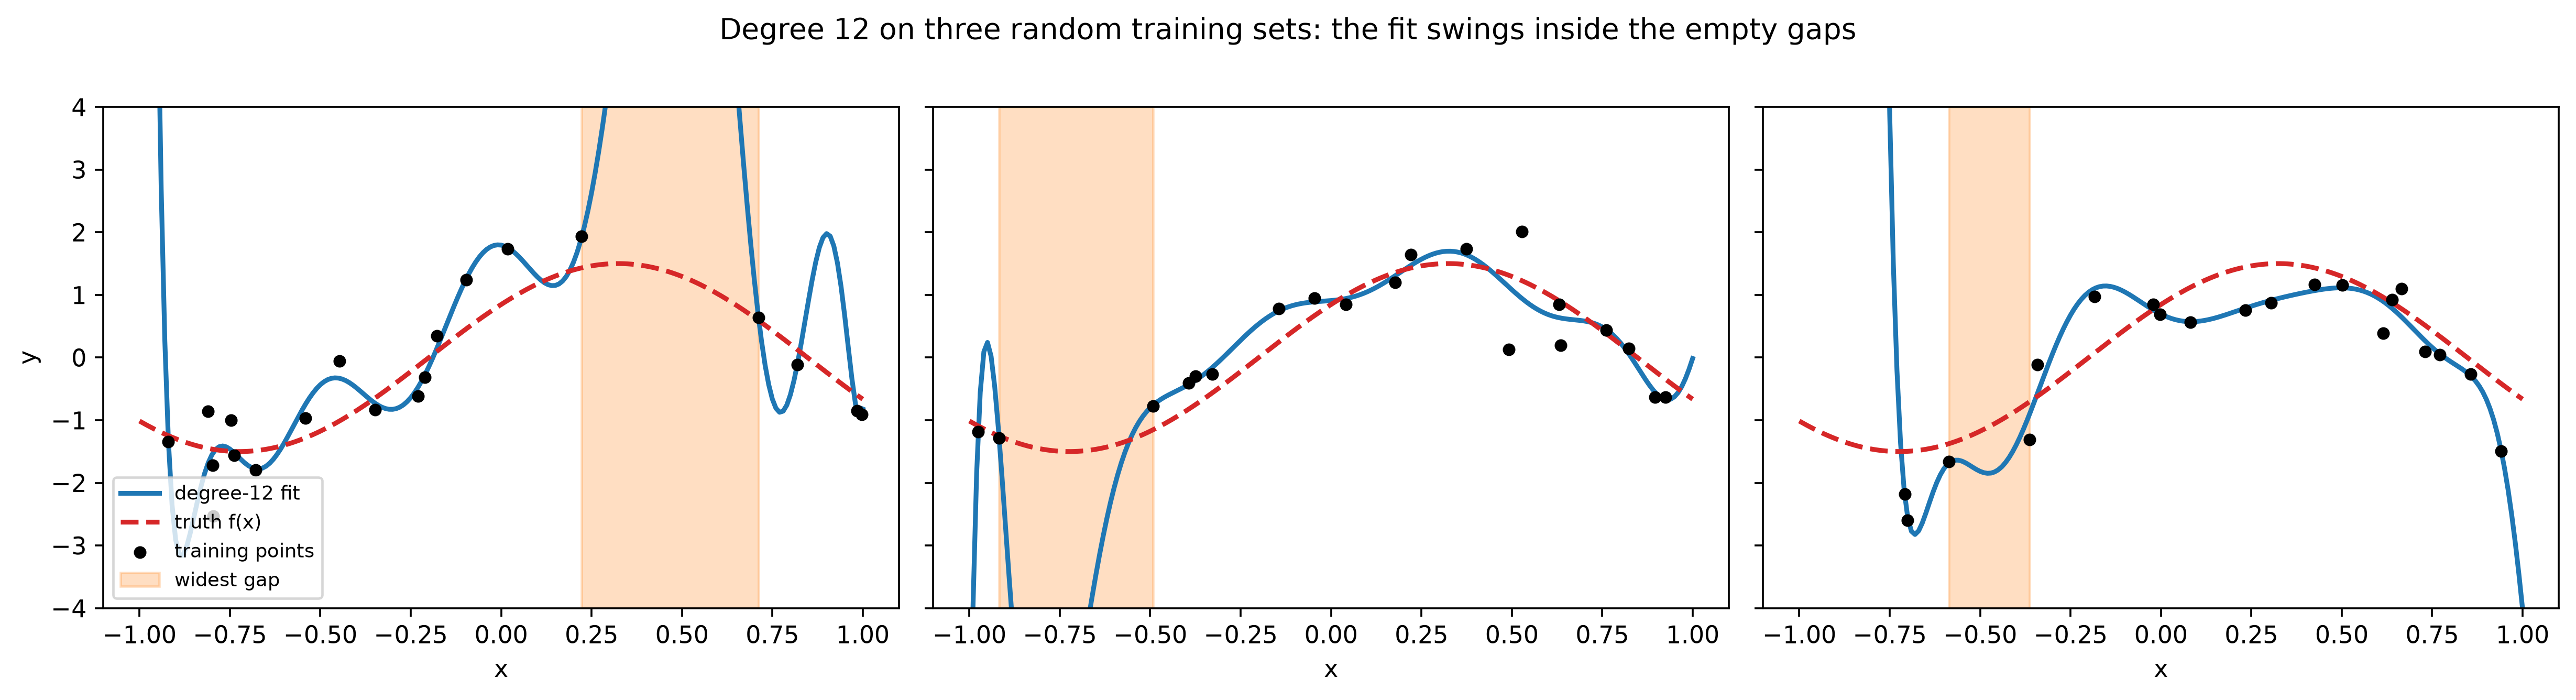

In [48]:
# a picture of the cause: three random training sets and their degree-12 fits
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax in axes:
    x_r = np.sort(rng.uniform(-1.0, 1.0, N_TRAIN))                       # one random training set
    y_r = f_true(x_r) + rng.normal(0.0, NOISE_SD, size=N_TRAIN)
    w = fit_poly(x_r, y_r, 12)
    gaps = np.diff(x_r)                                                  # distances between neighbouring inputs

    ax.plot(X_EVAL, predict_poly(X_EVAL, w), color="tab:blue", lw=2, label="degree-12 fit")
    ax.plot(X_EVAL, F_EVAL, color="tab:red", ls="--", lw=2, label="truth f(x)")
    ax.scatter(x_r, y_r, color="black", s=18, zorder=3, label="training points")
    biggest = np.argmax(gaps)                                            # where the widest empty gap is
    ax.axvspan(x_r[biggest], x_r[biggest + 1], color="tab:orange", alpha=0.25, label="widest gap")
    ax.set_ylim(-4, 4)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="lower left")
plt.suptitle("Degree 12 on three random training sets: the fit swings inside the empty gaps", y=1.0)
plt.tight_layout()
plt.show()

**Line by line**

- Each panel draws one random training set, fits a degree-12 polynomial and plots it against the truth.
- `np.diff(x_r)` : the distances between neighbouring sorted inputs, so `gaps[i]` is the empty stretch between
  point `i` and point `i+1`.
- `np.argmax(gaps)` : the position of the widest gap, and `ax.axvspan(left, right, ...)` shades that vertical
  band.
- `ax.set_ylim(-4, 4)` : the fits leave this range entirely in places, which is the point; without the limit the
  panels would be unreadable.

**Reading the panels.** The blue curve follows the truth reasonably where points are dense, and departs from it
inside or near the shaded gap, often violently, and again just past the outermost point at each end. Each panel
is a different training set, and the excursions appear in different places with different sizes. That is exactly
what "high variance" means, and it is why the averaged number in the table was so large.

**What to take away from Exercise 4**

1. More data reduces variance and leaves bias untouched, so it allows a more complex model, up to the point
   where bias has already vanished.
2. More noise inflates variance in proportion to $\sigma^2$ and leaves bias untouched, so it calls for a simpler
   model.
3. Complexity is not the parameter count. A fixed degree-15 model sweeps the whole trade-off as $\lambda$ varies.
4. Where the data lies matters as much as how much of it there is. A flexible model is unconstrained wherever
   there are no points.

---
# Closing summary

The four exercises each push on one part of the same framework.

| exercise | what was varied | what stayed fixed | the resulting lesson |
|---|---|---|---|
| 1 | the loss function | the world, the model, the posterior | the loss chooses the decision threshold, and every "best classifier" claim is relative to a loss |
| 2 | the shape of the class-conditional densities | the priors, the class centres, the classifiers | matching the model family to the truth removes approximation error; the Bayes error rate measures overlap, not boundary shape |
| 3 | where the "new datasets" come from | the world and the model family | resampling estimates variance from one dataset, never bias, and held-out error is what you actually need |
| 4 | data size, noise, regularisation, input positions | the truth $f$ | complexity should be chosen to suit the data you have, not fixed in advance |

**Three sentences worth remembering**

1. Decision theory separates the **model** (which produces $P(c \mid x)$ or an estimate of $E[Y \mid X]$) from the
   **decision** (which applies a loss to that output), and the two can be changed independently.
2. The Bayes error rate and $\sigma^2$ are floors set by the world; the gap between a trained model and the floor
   is the model's own fault, and it splits into bias and variance.
3. Training error measures how well a model fits data it has already seen, so it always prefers more complexity;
   only held-out data can find the bottom of the U.

**If you want to go further**, three natural extensions of this notebook:

* Implement k-fold cross-validation and use it to choose the polynomial degree, then compare its choice with
  the true best degree from Part 5, repeated over many datasets.
* Repeat the bias-variance study with k-NN regression, using $k$ as the complexity knob. Remember it runs
  backwards, like $\lambda$: small $k$ is complex.
* Return to the classification world and estimate bias and variance for the classifiers of Part 3 by retraining
  each on many fresh training sets, then relate the results to the decision-boundary pictures.